##                                              DASC-5997 FINAL PROJECT CODE

##                                              HARSHITHA MADHURI GARIKAPATI

##                                                GUIDANCE BY PROFESSOR LEI JIN
# IMPACT OF MNAR MISSING DATA ON DATASET INTEGRITY, PREDICTIVE MODELING & TEXT ANALYSIS – A COMPARATIVE STUDY USING R!

## 1. Required Libraries

In [1]:
# ---------------------------
# Libraries
# ---------------------------
library(stringr)

required_pkgs <- c(
  "dplyr", "ggplot2", "tidyr", "mice", "corrplot", "reshape2",
  "caret", "e1071", "randomForest","syuzhet", "tm", "stringr", "lubridate", "scales", "wordcloud", "tidytext"
)
library(syuzhet)
library(dplyr)
library(ggplot2)
library(stringr)
library(tm)
library(purrr)

for (p in required_pkgs) {
  if (!requireNamespace(p, quietly = TRUE)) install.packages(p)
  library(p, character.only = TRUE)
}
quiet_library <- function(pkg) {
  suppressPackageStartupMessages(
    suppressWarnings(
      library(pkg, character.only = TRUE)
    )
  )
}

required_pkgs <- c(
  "dplyr", "ggplot2", "tidyr", "mice", "corrplot", "reshape2",
  "caret", "e1071", "randomForest", "lubridate", "scales",
  "wordcloud", "tidytext"
)

for (p in required_pkgs) {
  if (!requireNamespace(p, quietly = TRUE)) {
    install.packages(p)
  }
  quiet_library(p)
}


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: NLP


Attaching package: ‘NLP’


The following object is masked from ‘package:ggplot2’:

    annotate



Attaching package: ‘mice’


The following object is masked from ‘package:stats’:

    filter


The following objects are masked from ‘package:base’:

    cbind, rbind


corrplot 0.95 loaded


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths


Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift



Attaching package: ‘e1071’


The following object is masked from ‘package:ggplot2’:

    element


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked fro

## 2. Loading the dataset

In [2]:
df <- "Instagram-data_CURRENT.csv"

if (!file.exists(df)) {
  stop("Data file not found. Please put 'Instagram-data_CURRENT.csv' in working directory.")
}

plots_dir <- "plots"
if (!dir.exists(plots_dir)) dir.create(plots_dir)

# load file correctly
df_raw <- read.csv(df, stringsAsFactors = FALSE)
cat("Loaded data:", nrow(df_raw), "rows x", ncol(df_raw), "cols\n\n")

# Quick glimpses
str(df_raw)
print(summary(df_raw))
print(head(df_raw, 8))

Loaded data: 176 rows x 15 cols

'data.frame':	176 obs. of  15 variables:
 $ Date           : chr  "12/10/2021" "12/11/2021" "12/12/2021" "12/13/2021" ...
 $ Impressions    : int  3920 5394 4021 4528 2518 3884 2621 3541 3749 4115 ...
 $ From.Home      : int  2586 2727 2085 2700 1704 2046 1543 2071 2384 2609 ...
 $ From.Hashtags  : int  1028 1838 1188 621 255 1214 599 628 857 1104 ...
 $ From.Explore   : int  619 1174 0 932 279 329 333 500 248 178 ...
 $ From.Other     : int  56 78 533 73 37 43 25 60 49 46 ...
 $ Saves          : int  98 194 41 172 96 74 22 135 155 122 ...
 $ Comments       : int  9 7 11 10 5 7 5 4 6 6 ...
 $ Shares         : int  5 14 1 7 4 10 1 9 8 3 ...
 $ Likes          : int  162 224 131 213 123 144 76 124 159 191 ...
 $ Profile.Visits : int  35 48 62 23 8 9 26 12 36 31 ...
 $ Follows        : int  2 10 12 8 0 2 0 6 4 6 ...
 $ Conversion.Rate: num  5.71 20.83 19.35 34.78 0 ...
 $ Caption        : chr  "Here are some of the most important data visualizations that ev

### (2.1) Remove duplicates

In [3]:
dup_count <- sum(duplicated(df_raw))
cat("Duplicate rows found:", dup_count, "\n")
if (dup_count > 0) df_raw <- df_raw[!duplicated(df_raw), ]

Duplicate rows found: 0 


### (2.2) Convert probable numeric columns


In [4]:
### We'll keep user columns intact, but extract numeric columns safely:
df <- df_raw

# Replace empty strings with NA for safety
df[df == ""] <- NA

### (2.3) Coerce columns that look numeric into numeric

In [5]:
# We use as.numeric after removing commas, dollar signs, etc.
coerce_numeric_one <- function(x) {
  if (is.numeric(x)) return(x)
  # remove commas and currency symbols then attempt numeric conversion
  if (is.character(x)) {
    x2 <- gsub(",", "", x)
    x2 <- gsub("\\$", "", x2)
    x2 <- gsub("%", "", x2)
    # if it looks numeric now, convert; else return original
    if (all(is.na(x2) | grepl("^[0-9\\.-]+$", x2))) {
      return(as.numeric(x2))
    } else {
      return(x)
    }
  }
  return(x)
}
df[] <- lapply(df, coerce_numeric_one)

### (2.4) Replace obvious negatives in numeric columns with NA:

In [6]:
df <- df %>% mutate(across(where(is.numeric), ~ ifelse(. < 0, NA, .)))

### (2.5) Build df_num with only numeric columns and force base R numeric type

In [7]:
df_num <- df %>% select(where(is.numeric))
if (ncol(df_num) == 0) stop("No numeric columns found. Need numeric columns like Likes, Comments, Followers.")
df_num[] <- lapply(df_num, function(x) as.numeric(as.vector(x))) # force numeric double

cat("Numeric columns used:", paste(names(df_num), collapse = ", "), "\n")
cat("Rows and columns in numeric DF:", dim(df_num), "\n\n")
                   

Numeric columns used: Impressions, From.Home, From.Hashtags, From.Explore, From.Other, Saves, Comments, Shares, Likes, Profile.Visits, Follows, Conversion.Rate 
Rows and columns in numeric DF: 176 12 



## 3. Text Cleaning on Caption Column

In [8]:
# 2. Load Your Dataset
# ----------------------------------
df <- read.csv("Instagram-data_CURRENT.csv", stringsAsFactors = FALSE)
#head(df)   # preview

In [9]:
install.packages("wordcloud")
install.packages("RColorBrewer")

library(wordcloud)
library(RColorBrewer)

Installing package into ‘/home/hgarikapati/R/x86_64-pc-linux-gnu-library/4.2’
(as ‘lib’ is unspecified)

Warning message:
“unable to access index for repository https://cran.r-project.org/src/contrib:
  cannot open URL 'https://cran.r-project.org/src/contrib/PACKAGES'”
Warning message:
“package ‘wordcloud’ is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”
Installing package into ‘/home/hgarikapati/R/x86_64-pc-linux-gnu-library/4.2’
(as ‘lib’ is unspecified)

Warning message:
“unable to access index for repository https://cran.r-project.org/src/contrib:
  cannot open URL 'https://cran.r-project.org/src/contrib/PACKAGES'”
Warning message:
“package ‘RColorBrewer’ is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/d

In [10]:
df <- df %>%
  mutate(clean_caption = tolower(Caption),
         clean_caption = str_replace_all(clean_caption, "[^a-z0-9\\s]", ""))  # remove symbols/punctuation

df %>% select(Caption, clean_caption) %>% head()

,Caption,clean_caption
,<chr>,<chr>
1,Here are some of the most important data visualizations that every Financial Data Analyst/Scientist should know.,here are some of the most important data visualizations that every financial data analystscientist should know
2,Here are some of the best data science project ideas on healthcare. If you want to become a data science professional in the healthcare domain then you must try to work on these projects.,here are some of the best data science project ideas on healthcare if you want to become a data science professional in the healthcare domain then you must try to work on these projects
3,Learn how to train a machine learning model and giving inputs to your trained model to make predictions using Python.,learn how to train a machine learning model and giving inputs to your trained model to make predictions using python
4,Here’s how you can write a Python program to detect whether a sentence is a question or not. The idea here is to find the words that we see in the beginning of a question in the beginning of a sentence.,heres how you can write a python program to detect whether a sentence is a question or not the idea here is to find the words that we see in the beginning of a question in the beginning of a sentence
5,Plotting annotations while visualizing your data is considered good practice to make the graphs self-explanatory. Here is an example of how you can annotate a graph using Python.,plotting annotations while visualizing your data is considered good practice to make the graphs selfexplanatory here is an example of how you can annotate a graph using python
6,Here are some of the most important soft skills that every data scientist should have.,here are some of the most important soft skills that every data scientist should have


### 3.1. Word Frequency Count

In [11]:
word_freq <- df$clean_caption %>%
  str_split("\\s+") %>%
  unlist() %>%
  table() %>%
  sort(decreasing = TRUE)

head(word_freq, 20)   # show top 20 most common words

# Convert frequency table -> data frame
word_freq_df <- as.data.frame(word_freq)
colnames(word_freq_df) <- c("word", "freq")

.
     the       of       to     data      you        a     here      are 
     272      225      194      182      168      136      127      116 
      in      and  science   python     that      for       is     some 
     113       99       98       94       84       80       80       80 
learning      how    using    learn 
      78       73       69       68 

### 3.2. TOP 20 most common words in captions

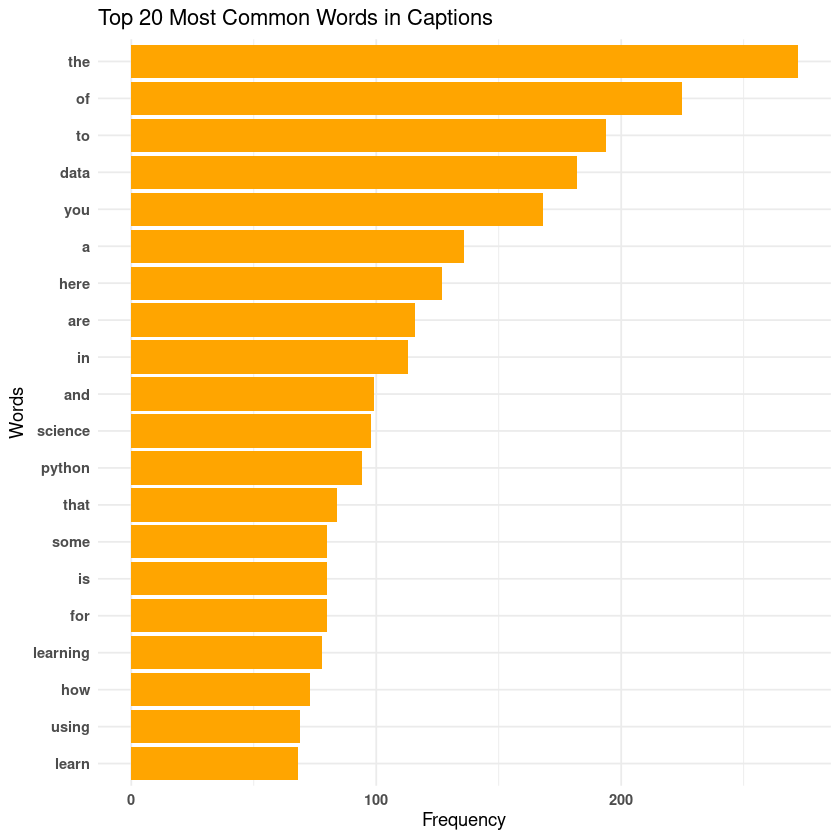

In [12]:
top_words <- word_freq_df %>% 
  filter(word != "") %>% 
  slice_max(freq, n = 20)

p_bar <- ggplot(top_words, aes(x = reorder(word, freq), y = freq)) +
  geom_col(fill = "orange") +
  coord_flip() +
  labs(title = "Top 20 Most Common Words in Captions",
       x = "Words",
       y = "Frequency") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(face = "bold"),
    axis.text.y = element_text(face = "bold")
  )

print(p_bar)


## 4. Clean Text and Few Visualisations

In [13]:
df <- df %>%
  mutate(clean_caption = Caption %>%
           tolower() %>%
           str_replace_all("[^a-z0-9\\s]", ""))

### 4.1. Remove Stopwords (meaningless words)

In [14]:
data("stop_words")   # from tidytext
words_df <- df %>%
  unnest_tokens(word, clean_caption) %>%
  filter(!word %in% stop_words$word) %>%   # REMOVE "the, or, and, is, …"
  filter(word != "")
# Frequency table
word_freq_df <- words_df %>%
  count(word, sort = TRUE)
head(word_freq_df)

,word,n
,<chr>,<int>
1,data,182
2,science,98
3,python,94
4,learning,78
5,learn,68
6,machine,61


### 4.2. Filtering only profession-related words

In [15]:
# =========================================================
# 4. Profession Dictionary
# =========================================================
profession_dict <- c(
  # Healthcare (7)
  "doctor","nurse","hospital","healthcare","clinic","medical","medicine",

  # Finance (7)
  "finance","financial","investment","banking","analyst","accounting","economics",

  # Data / Tech (14)
  "data","scientist","science","analysis","machine","learning","developer",
  "engineer","software","ai","ml","statistics","model","programming",

  # Research / Lab (5)
  "research","lab","chemistry","biology","experiment",

  # Education (6)
  "teacher","tutor","professor","education","student","training"
)

# =========================================================
# 5. Filter Only Profession-Related Words
# =========================================================
profession_keywords <- word_freq_df %>%
  filter(word %in% profession_dict)

profession_keywords

word,n
<chr>,<int>
data,182
science,98
learning,78
machine,61
analysis,48
programming,15
scientist,11
model,10
healthcare,8


### 4.3. Define Category Weights (Non-Emotion Scoring) and Merging scores

In [16]:
# =========================================================
# 6. Define Category Weights (Non-Emotion Scoring)
# =========================================================
profession_weights <- data.frame(
  word = profession_dict,
  category = c(
    rep("health", 7),
    rep("finance", 7),
    rep("data_tech", 14),
    rep("science_research", 5),
    rep("education", 6)
  ),
  weight = c(
    rep(2, 7),
    rep(2, 7),
    rep(3, 14),
    rep(2, 5),
    rep(1, 6)
  )
)

# =========================================================
# 7. Merge Scores
# =========================================================
profession_scored <- profession_keywords %>%
  left_join(profession_weights, by = "word") %>%
  mutate(score = log1p(n) * weight) %>%   # log scaling prevents domination
  arrange(desc(score))

profession_scored


word,n,category,weight,score
<chr>,<int>,<chr>,<dbl>,<dbl>
data,182,data_tech,3,15.628458
science,98,data_tech,3,13.785360
learning,78,data_tech,3,13.108344
machine,61,data_tech,3,12.381403
analysis,48,data_tech,3,11.675461
programming,15,data_tech,3,8.317766
scientist,11,data_tech,3,7.454720
model,10,data_tech,3,7.193686
healthcare,8,health,2,4.394449


### 4.4. Plot Profession Scores

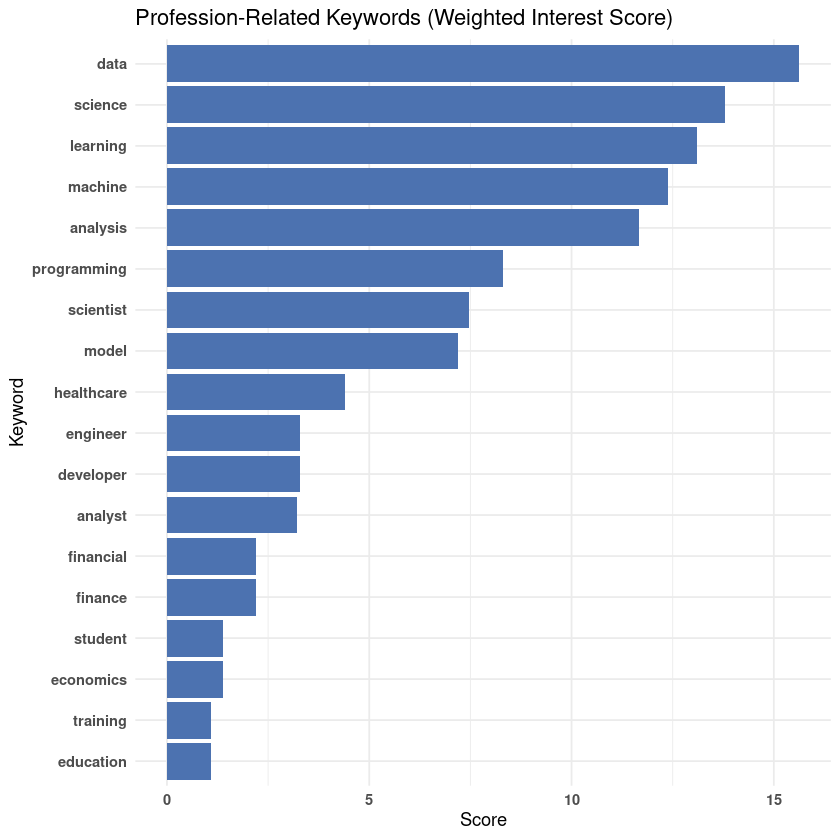

In [17]:
ggplot(profession_scored, aes(x = reorder(word, score), y = score)) +
  geom_col(fill = "#4C72B0") +
  coord_flip() +
  labs(title = "Profession-Related Keywords (Weighted Interest Score)",
       x = "Keyword",
       y = "Score") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(face = "bold"),
    axis.text.y = element_text(face = "bold")
  )


### 4.5. Histogram of numeric variables

No id variables; using all as measure variables



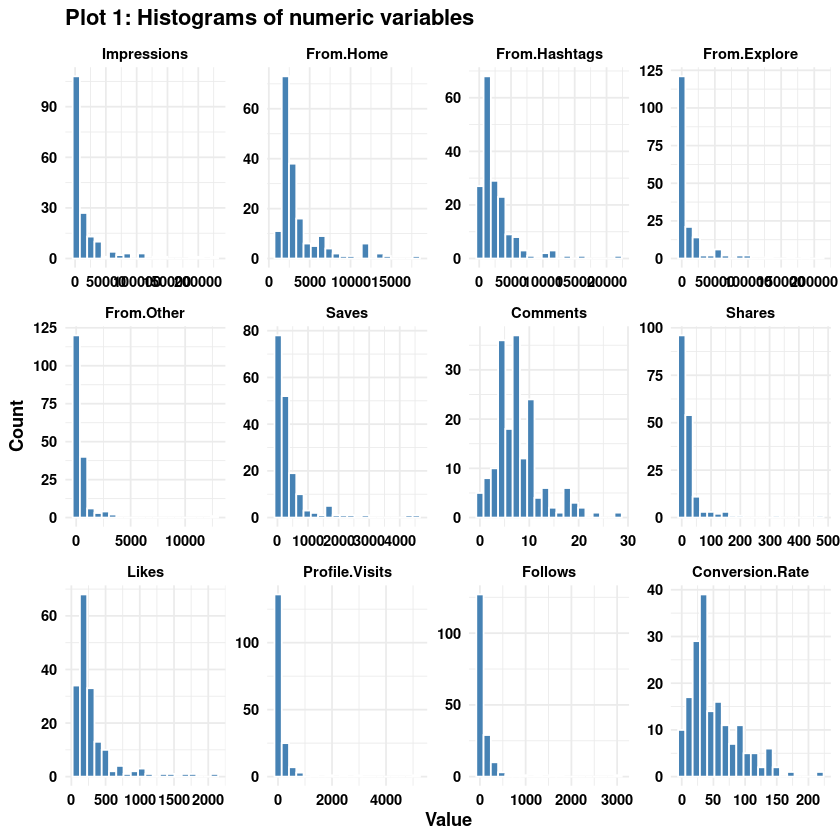

In [18]:
# Helper to save ggplot
save_plot <- function(plot_obj, filename, width=45, height=20) {
  ggsave(filename = file.path(plots_dir, filename), plot = plot_obj, width = width, height = height)
}

# Plot 1: Histograms of numeric variables
p1 <- ggplot(reshape2::melt(df_num), aes(x = value)) +
  geom_histogram(bins = 20, fill = "steelblue", color = "white") +
  facet_wrap(~variable, scales = "free") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(face="bold", color="black"),
    axis.text.y = element_text(face="bold", color="black"),
    axis.title.x = element_text(face="bold", color="black"),
    axis.title.y = element_text(face="bold", color="black"),
    strip.text = element_text(face="bold", color="black"),  # facet labels bold
    plot.title = element_text(face="bold")
  ) +
  labs(title = "Histograms of numeric variables", x = "Value", y = "Count")

print(p1)
save_plot(p1, "01_histograms.png")


### 4.6. Boxplot of variables

No id variables; using all as measure variables



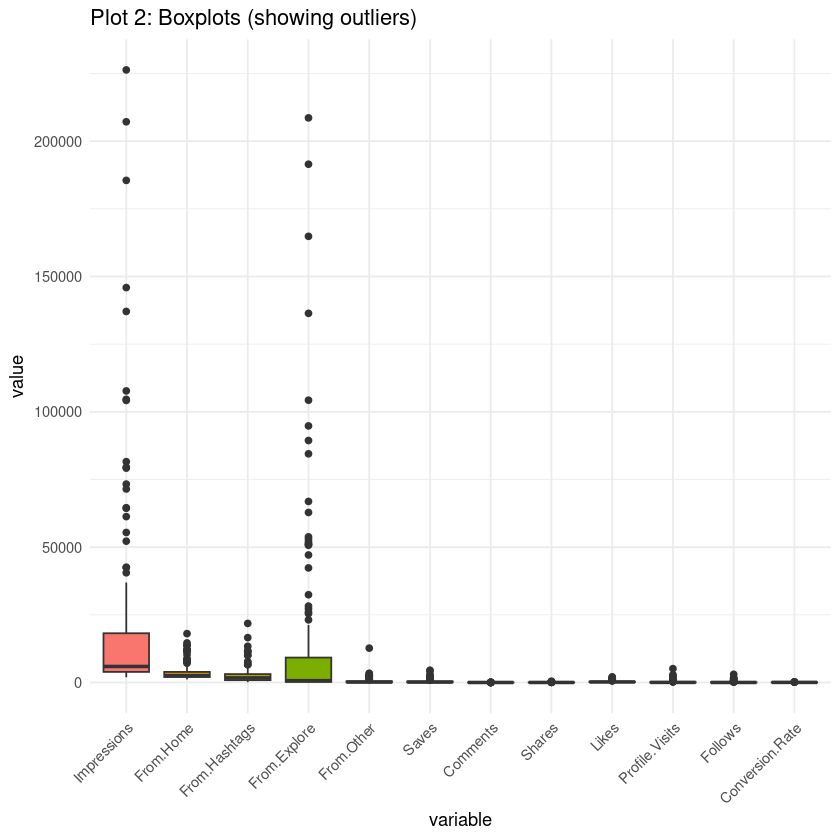

In [19]:
p2 <- ggplot(reshape2::melt(df_num), aes(x = variable, y = value, fill = variable)) +
  geom_boxplot() + theme_minimal() +
  theme(legend.position = "none", axis.text.x = element_text(angle=45, hjust=1)) +
  labs(title = "Plot 2: Boxplots (showing outliers)")
print(p2); save_plot(p2, "02_boxplots.png")

### 4.7. density plots

No id variables; using all as measure variables



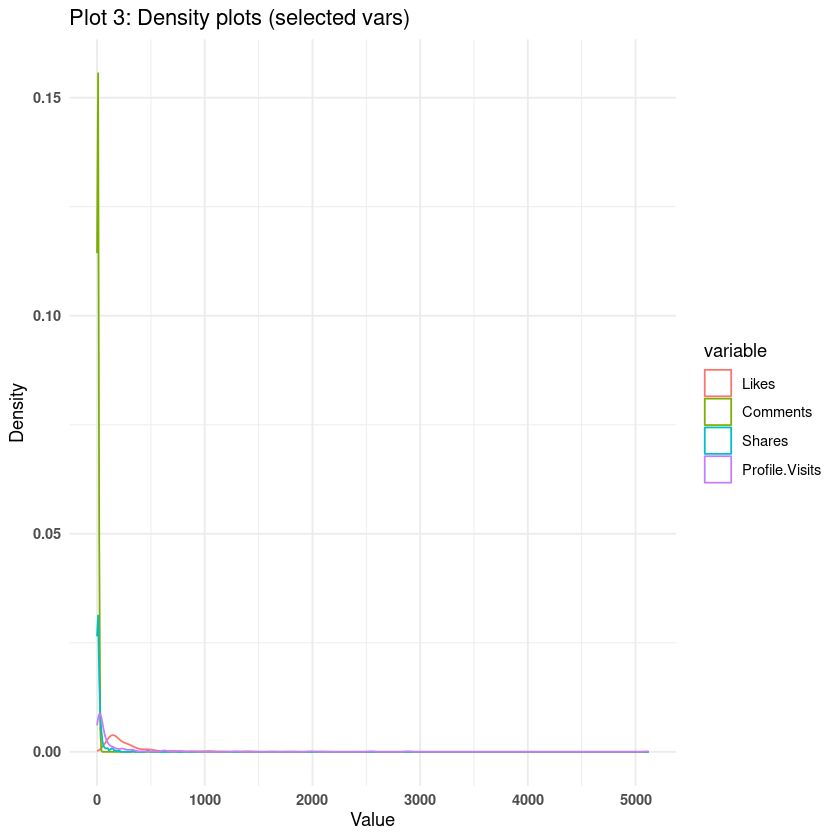

In [21]:
main_vars <- intersect(c("Likes","Comments","Shares","Profile.Visits","Followers"), names(df_num))
if (length(main_vars) < 3) main_vars <- names(df_num)[1:min(4, ncol(df_num))]
p3 <- ggplot(
  df_num %>% select(all_of(main_vars)) %>% reshape2::melt(),
  aes(x = value, color = variable)
) +
  geom_density(na.rm = TRUE) +
  theme_minimal() +
  labs(
    title = "Plot 3: Density plots (selected vars)",
    x = "Value",
    y = "Density"
  ) +
  theme(
    axis.text.x = element_text(face = "bold"),
    axis.text.y = element_text(face = "bold")
  )

print(p3)
save_plot(p3, "03_densities.png")


### 4.8. pairwise scatter plot for first 6 numeric columns

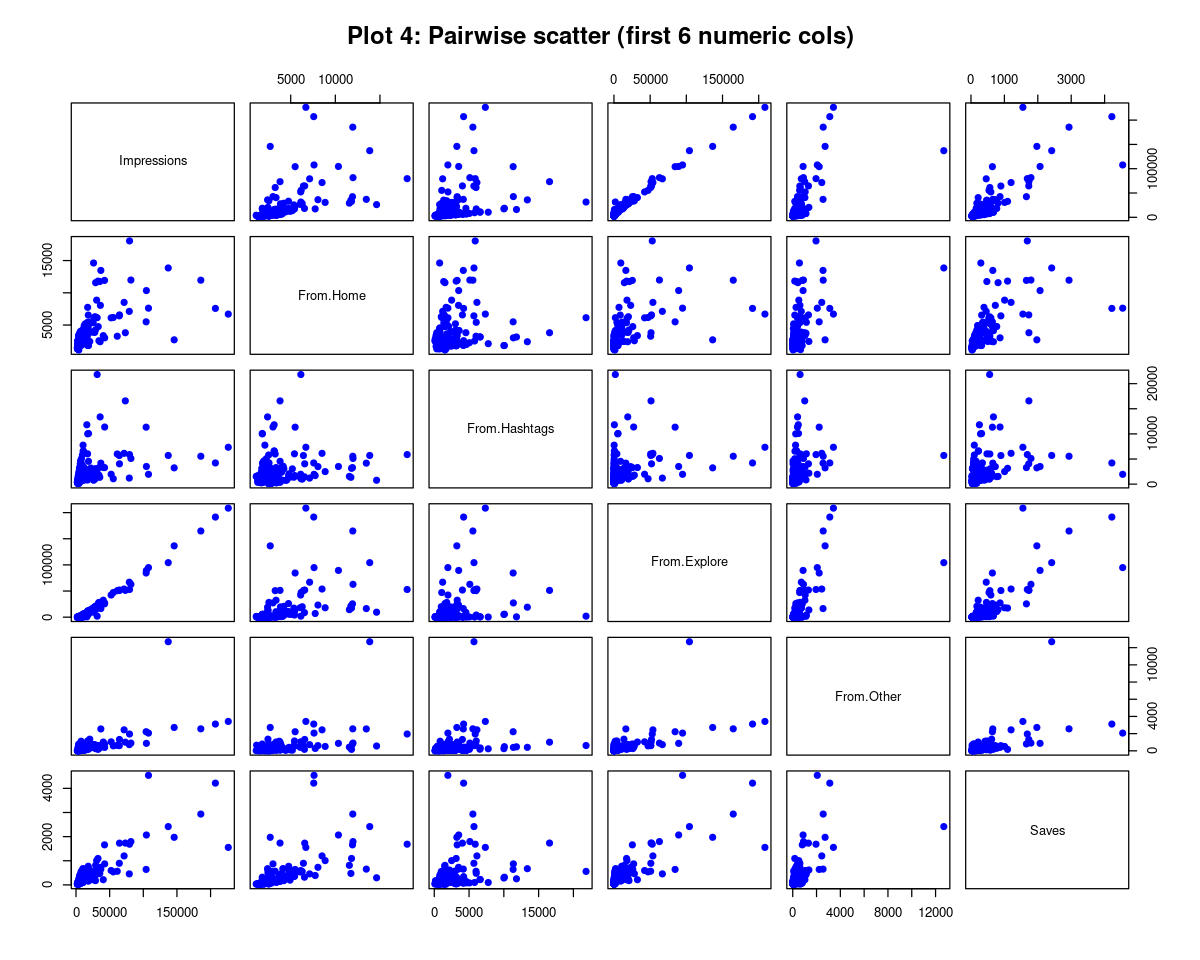

In [22]:
# Make the Jupyter plot output larger
options(repr.plot.width = 10, repr.plot.height = 8)  # increase width & height (inches)
# Optional: tweak margins and label size
par(cex = 0.4, mar = c(2, 2, 2, 2))
# Now plot
pairs(df_num[, 1:min(6, ncol(df_num))],
      main = "Plot 4: Pairwise scatter (first 6 numeric cols)",
      col = "blue", pch = 19)

### 4.9. Correlation heatmap

Warning message in text.default(pos.xlabel[, 1], pos.xlabel[, 2], newcolnames, srt = tl.srt, :
“"tl.font" is not a graphical parameter”
Warning message in text.default(pos.ylabel[, 1], pos.ylabel[, 2], newrownames, col = tl.col, :
“"tl.font" is not a graphical parameter”
Warning message in title(title, ...):
“"tl.font" is not a graphical parameter”


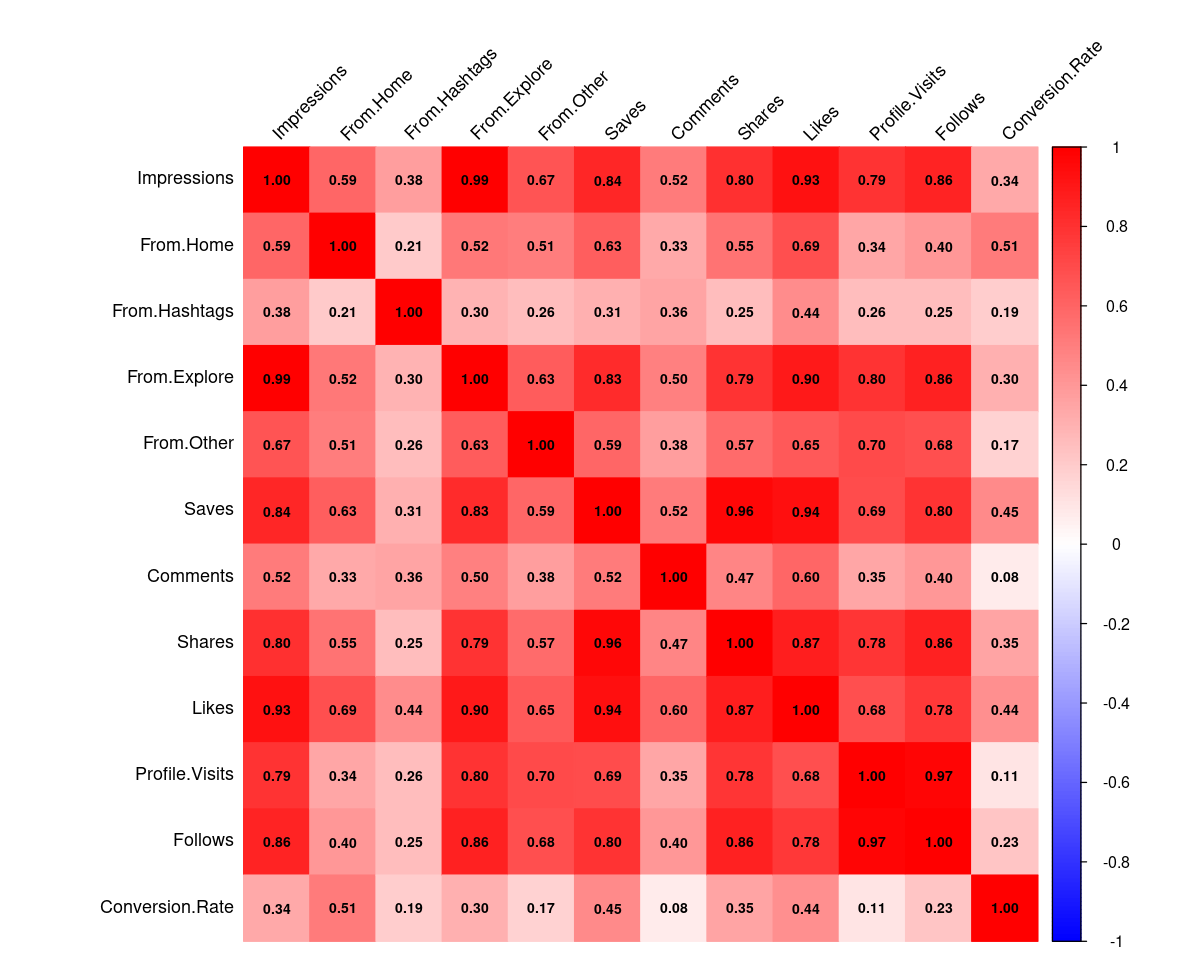

In [23]:
# Select numeric columns
numeric_df <- df %>% select(where(is.numeric))

# Compute correlation matrix
corr_matrix <- cor(numeric_df, use = "complete.obs")

# Display heatmap
corrplot(
  corr_matrix,
  method = "color",
  type = "full",
  addCoef.col = "black",      # show numbers
  tl.col = "black",           # label color
  tl.srt = 45,                # rotate labels
  tl.font = 2,                # <<< make axis labels bold
  col = colorRampPalette(c("blue", "white", "red"))(200),
  number.cex = 0.7,
  tl.cex = 0.9
)


### 4.10. PLOT Follows vs likes

`geom_smooth()` using formula = 'y ~ x'


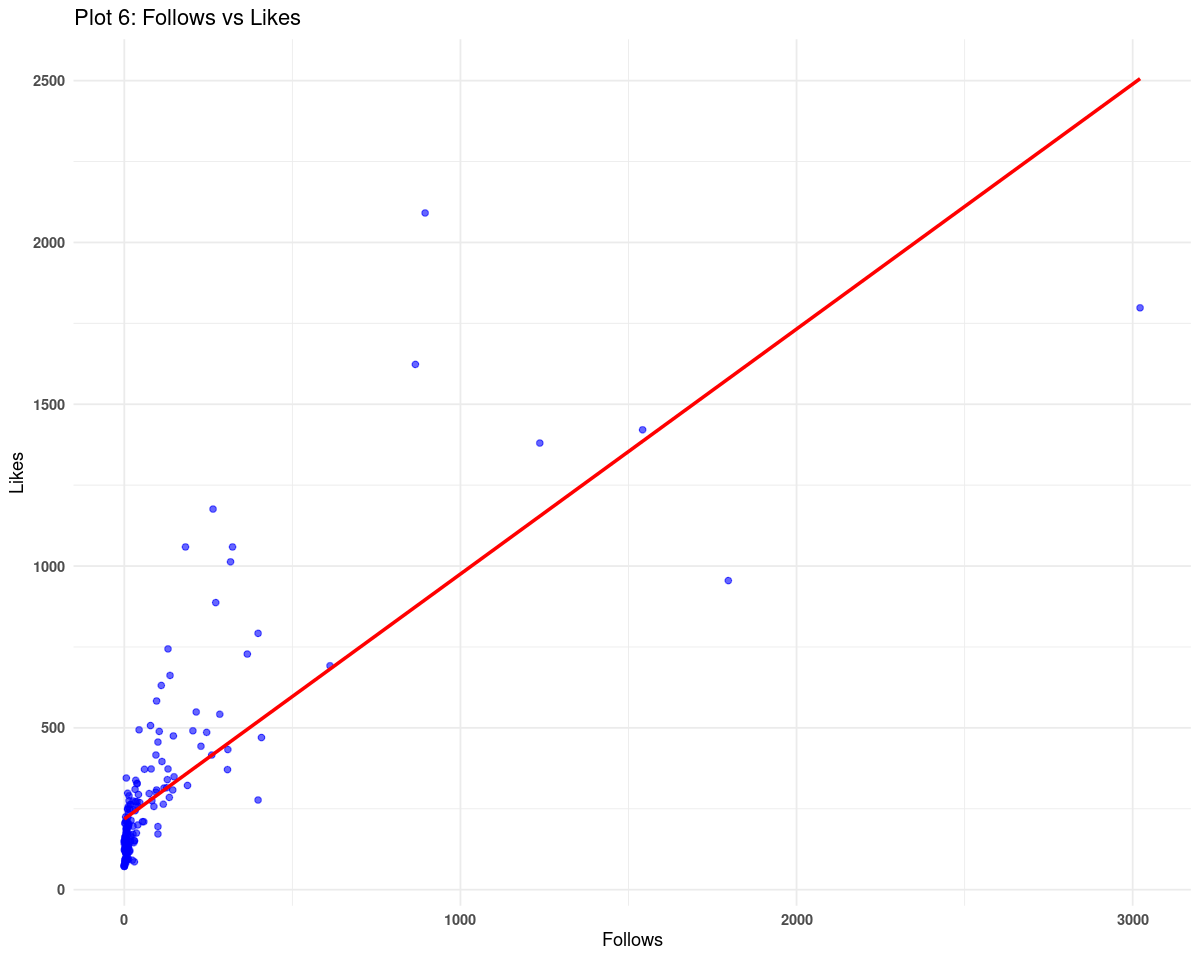

In [24]:
library(ggplot2)

if (all(c("Likes", "Follows") %in% names(df_num))) {
  p6 <- ggplot(df_num, aes(x = Follows, y = Likes)) +
    geom_point(alpha = 0.6, color = "blue") +
    geom_smooth(method = "lm", se = FALSE, color = "red") +
    theme_minimal() +
    labs(
      title = "Plot 6: Follows vs Likes",
      x = "Follows",
      y = "Likes"
    ) +
    theme(
      axis.text.x = element_text(face = "bold"),
      axis.text.y = element_text(face = "bold")
    )

  print(p6)
} else {
  print("⚠️ Columns 'Likes' or 'Follows' not found in df_num")
}



Attaching package: ‘gridExtra’


The following object is masked from ‘package:randomForest’:

    combine


The following object is masked from ‘package:dplyr’:

    combine


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


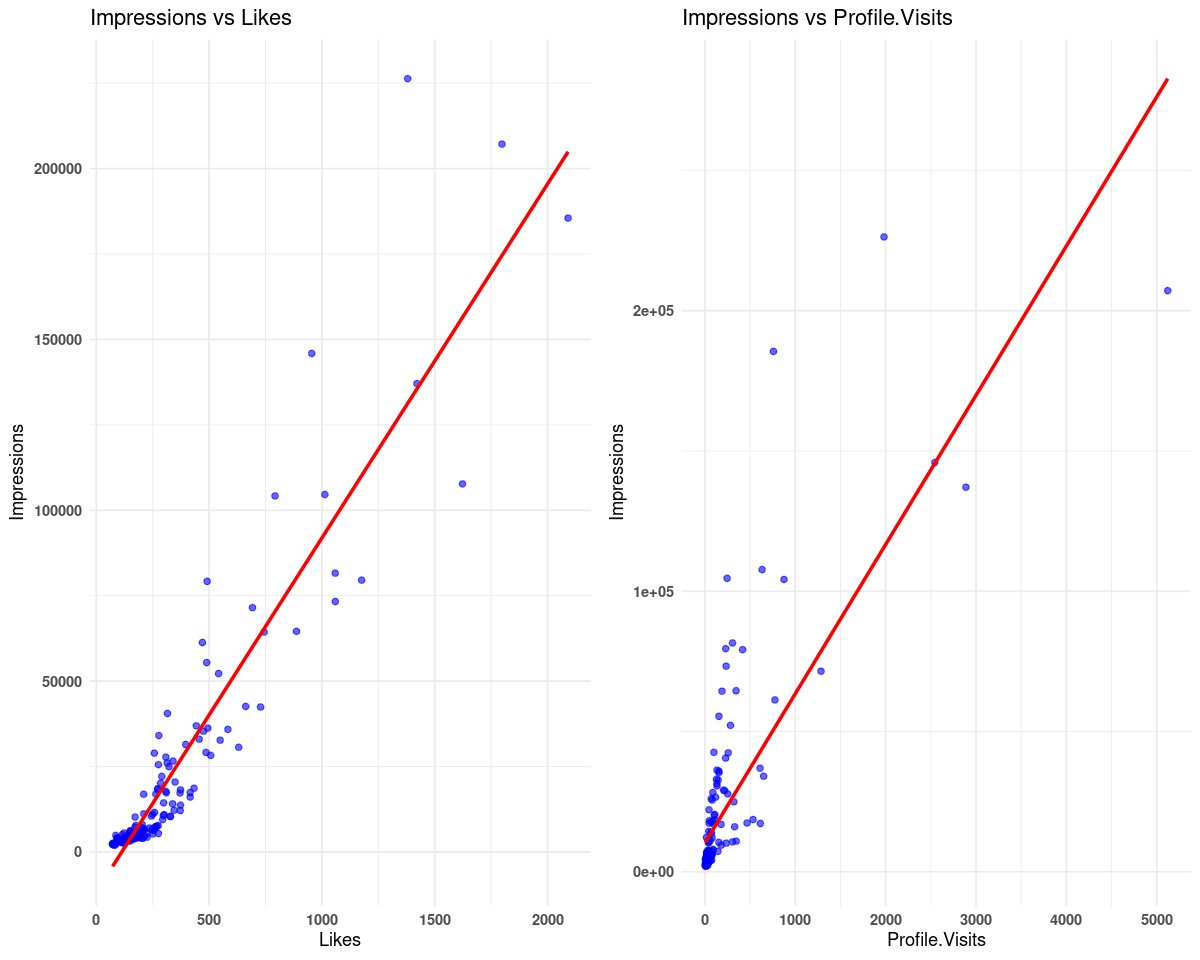

In [25]:
library(ggplot2)
library(gridExtra)

plot_impressions <- function(df, var_name) {
  
  ggplot(df, aes_string(x = var_name, y = "Impressions")) +
    geom_point(alpha = 0.6, color = "blue") +
    geom_smooth(method = "lm", se = FALSE, color = "red") +
    theme_minimal() +
    labs(
      title = paste("Impressions vs", var_name),
      x = var_name,
      y = "Impressions"
    ) +
    theme(
      axis.text.x = element_text(face = "bold"),
      axis.text.y = element_text(face = "bold")
    )
}

# Create two plots
p1 <- plot_impressions(df_num, "Likes")
p2 <- plot_impressions(df_num, "Profile.Visits")

# Display side-by-side
grid.arrange(p1, p2, ncol = 2)


### 4.11. Violin plot of numeric variables

No id variables; using all as measure variables



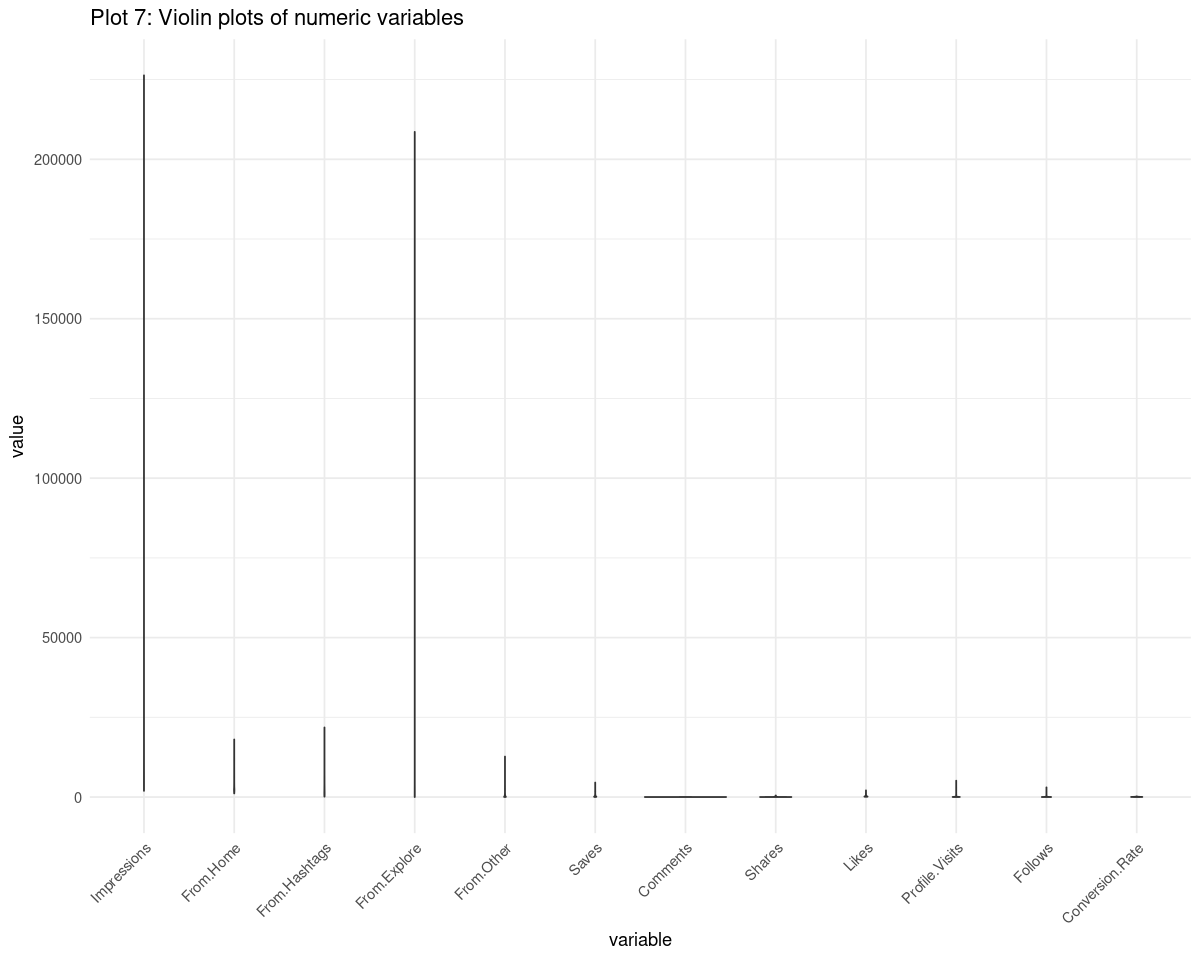

In [26]:
p7 <- ggplot(reshape2::melt(df_num), aes(x = variable, y = value, fill = variable)) +
  geom_violin(trim = TRUE) + theme_minimal() +
  theme(legend.position = "none", axis.text.x = element_text(angle=45, hjust=1)) +
  labs(title = "Plot 7: Violin plots of numeric variables")
print(p7); save_plot(p7, "07_violins.png")

### 4.12. outlier heatmap

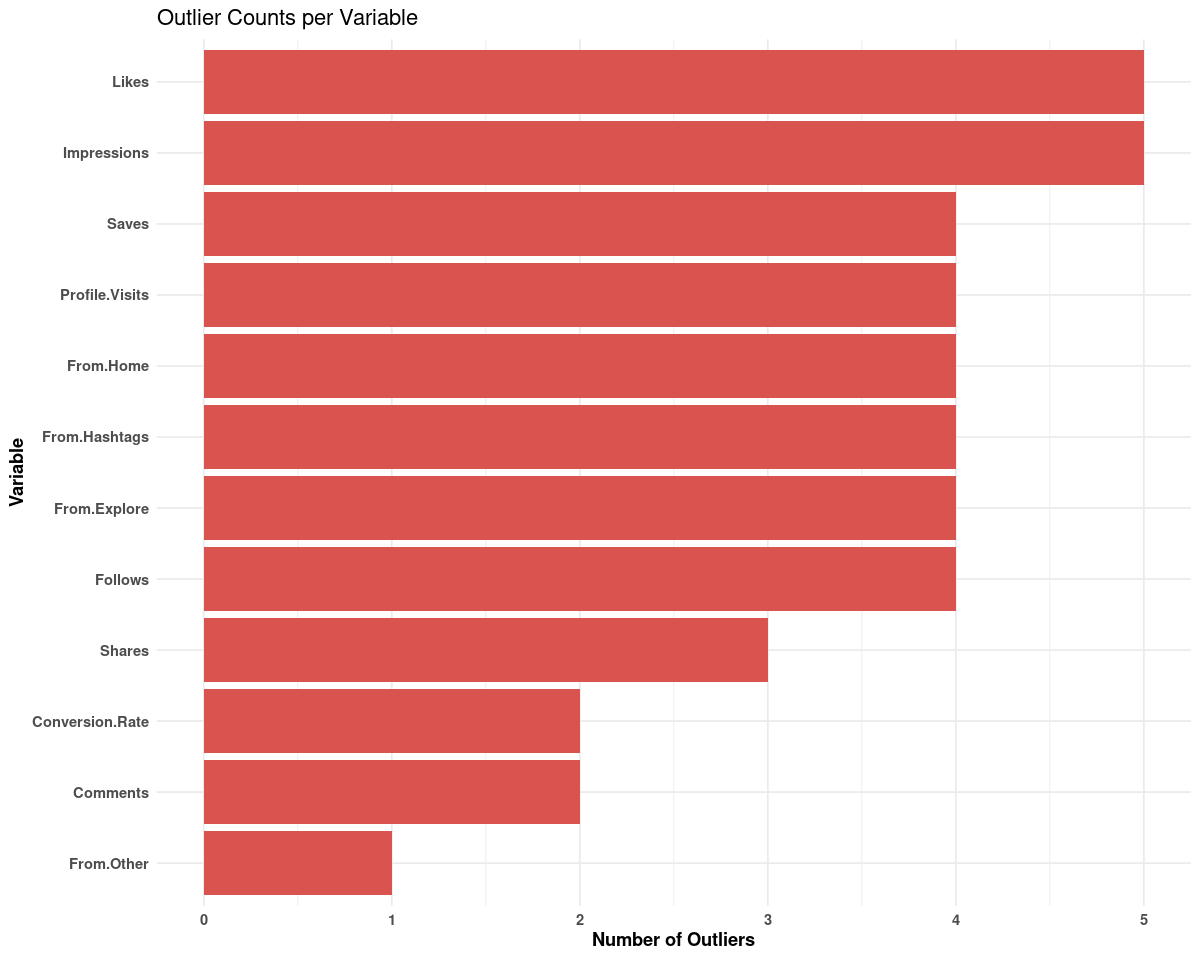

In [27]:
library(ggplot2)

# Compute z-scores
z_scores <- scale(df_num)
outliers_logical <- abs(z_scores) > 3

# Convert TRUE/FALSE → 1/0
outliers_numeric <- as.data.frame(lapply(as.data.frame(outliers_logical), as.numeric))

# Count outliers per variable
outlier_counts <- colSums(outliers_numeric, na.rm = TRUE)

# Build a clean data frame for ggplot
df_out <- data.frame(
  variable = names(outlier_counts),
  count = outlier_counts
)

ggplot(df_out, aes(x = reorder(variable, count), y = count)) +
  geom_col(fill = "#D9534F") +        # nice red color
  coord_flip() +                      # horizontal bars = easier to read
  theme_minimal() +
  labs(
    title = "Outlier Counts per Variable",
    x = "Variable",
    y = "Number of Outliers"
  ) +
  theme(
    axis.text.x = element_text(face = "bold"),
    axis.text.y = element_text(face = "bold"),
    axis.title.x = element_text(face = "bold"),
    axis.title.y = element_text(face = "bold")
  )

## 5. MISSING VALUES before MNAR

In [28]:
#missing_before <- colSums(is.na(df_num))
#    p10 <- ggplot(data.frame(variable = names(missing_before), missing = missing_before), aes(x = reorder(variable, -missing), y = missing)) +
#  geom_col(fill = "orange") + geom_text(aes(label=missing), vjust=1) + theme_minimal() +
#  theme(axis.text.x = element_text(angle=45, hjust=1)) + labs(title = "Plot 10: Missing values per variable (before MNAR)", x = "Variable", y = "Missing count")
# print(p10); save_plot(p10, "10_missing_before.png")
# # Count of plots saved:
# cat("Saved plots into", plots_dir, "folder. At least 10 visualizations created (some optional).\n\n")       

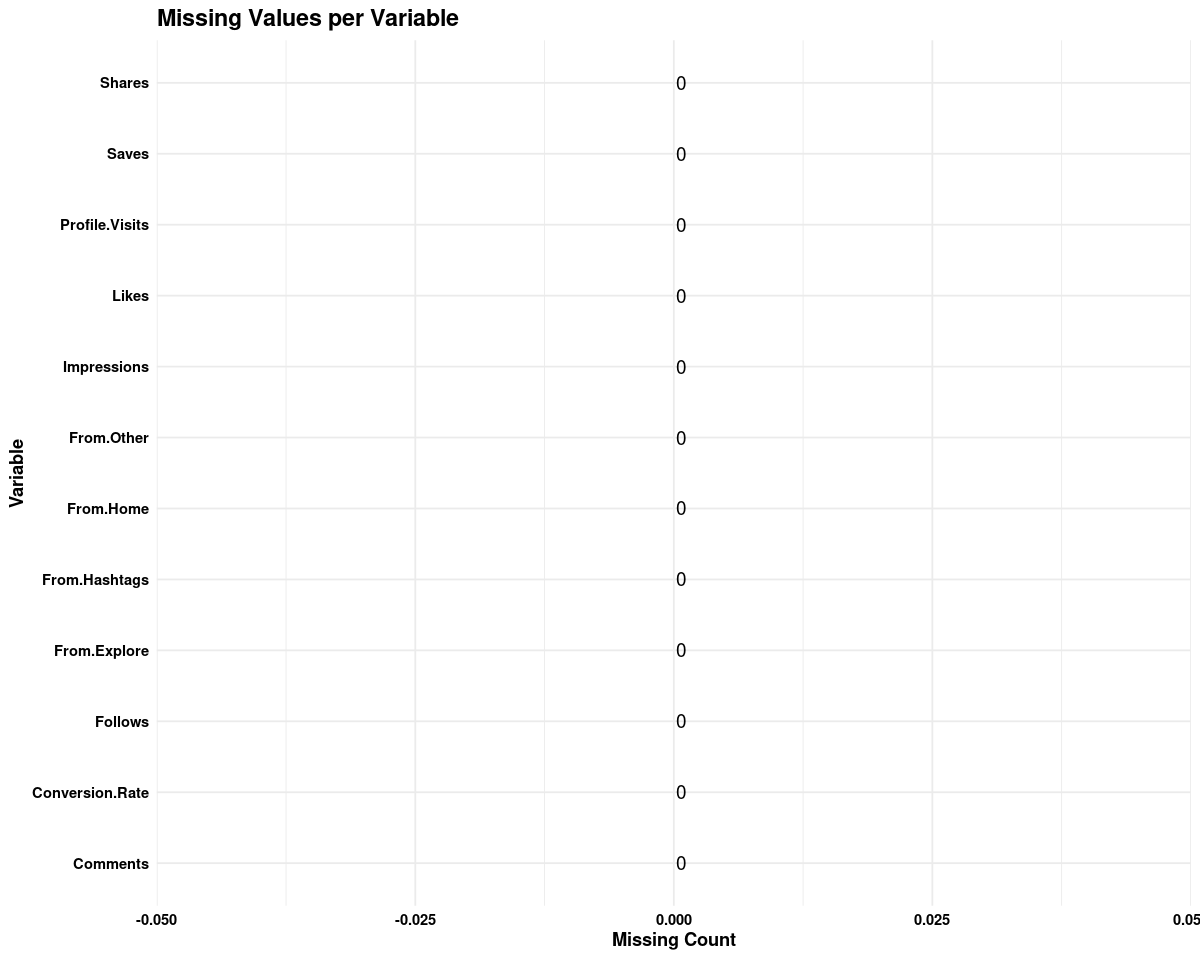

In [29]:
missing_before <- colSums(is.na(df_num))
p10 <- ggplot(data.frame(variable = names(missing_before), missing = missing_before),
              aes(x = reorder(variable, missing), y = missing)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  geom_text(aes(label = missing), hjust = -0.2, size = 4) +
  coord_flip() +
  theme_minimal() +
  labs(title = "Missing Values per Variable",
       x = "Variable", y = "Missing Count") +
  theme(
    plot.title = element_text(face="bold", size=14),
    axis.text.x = element_text(face="bold", color="black"),
    axis.text.y = element_text(face="bold", color="black"),
    axis.title.x = element_text(face="bold", color="black"),
    axis.title.y = element_text(face="bold", color="black")
  )

print(p10)
save_plot(p10, "10_missing_before_alternative1.png")


### 5.1. Generating MNAR Missingness

In [30]:
cat("--- Generating MNAR missingness ---\n")

# Interpretation: user said "Only x1, x5, x6 will have missing values".
# We'll take x1 to mean the 1st numeric column, x5 the 5th numeric col, x6 the 6th numeric col (if exist).
num_cols <- ncol(df_num)
cat("Number of numeric columns:", num_cols, "\n")

--- Generating MNAR missingness ---
Number of numeric columns: 12 


### 5.2. MNAR to numeric columns 

In [31]:
# Desired missing column indices (user pattern): 1,5,6
desired_idx <- c(1,2,4,6,8,10)
# Keep only indices that exist in this dataset
desired_idx <- desired_idx[desired_idx <= num_cols]
if (length(desired_idx) == 0) {
  # fallback: pick some columns (2nd and 3rd) if dataset too small
  desired_idx <- unique(pmax(1, head(seq_len(num_cols), 2)))
}
cat("Will apply MNAR to numeric column indices:", paste(desired_idx, collapse = ", "), "\n")
cat("Corresponding numeric column names:", paste(names(df_num)[desired_idx], collapse = ", "), "\n")


Will apply MNAR to numeric column indices: 1, 2, 4, 6, 8, 10 
Corresponding numeric column names: Impressions, From.Home, From.Explore, Saves, Shares, Profile.Visits 


### 5.3. Pattern used for ampute:

In [32]:
# Build patterns vector of length = number of numeric columns.
# NOTE: In mice::ampute, a pattern vector indicates which variables are observed (1) and missing (0) for that pattern.
# So to make columns desired_idx have missingness, set those positions to 0.
pattern_vec <- rep(1L, num_cols)
pattern_vec[desired_idx] <- 0L
# For readability, print pattern vector
cat("Pattern vector used for ampute():", paste(pattern_vec, collapse = ","), "\n")

Pattern vector used for ampute(): 0,0,1,0,1,0,1,0,1,0,1,1 


## 6. Missing values after MNAR: 

In [33]:
# Run ampute; it's possible ampute may fail for small datasets or certain inputs;
# we'll catch errors and fallback to a manual MNAR simulation if needed.
set.seed(123)
ampute_out <- tryCatch({
  ampute(df_num, patterns = pattern_vec, freq = 1, mech = "MNAR", prop = 0.2)
}, error = function(e) {
  message("ampute() failed with error: ", e$message, "\nFalling back to manual MNAR simulation.")
  NULL
})

if (!is.null(ampute_out) && !is.null(ampute_out$amp)) {
  data_with_missing <- ampute_out$amp
  cat("ampute() succeeded. Missing introduced. Summary:\n")
} else {
  # Fallback manual MNAR: make high-valued rows in desired columns more likely missing.
  data_with_missing <- df_num
  for (ci in desired_idx) {
    colname <- names(data_with_missing)[ci]
    colvals <- data_with_missing[[colname]]
    qq80 <- quantile(colvals, 0.8, na.rm = TRUE)
    # probability increases with value above qq80 (simple logistic)
    sigma <- sd(colvals, na.rm = TRUE)
    prob <- plogis((colvals - qq80) / (ifelse(is.na(sigma) || sigma==0, 1, sigma)))
    prob[is.na(prob)] <- 0
    # sample: scale down
    remove_mask <- runif(nrow(data_with_missing)) < (0.25 * prob)
    data_with_missing[[colname]][remove_mask] <- NA
  }
  cat("Manual MNAR fallback applied. Summary:\n")
}
print(colSums(is.na(data_with_missing)))
# Save the MNAR dataset if desired
# write.csv(data_with_missing, file="data_with_mi

ampute() succeeded. Missing introduced. Summary:
    Impressions       From.Home   From.Hashtags    From.Explore      From.Other 
             23              23               0              23               0 
          Saves        Comments          Shares           Likes  Profile.Visits 
             23               0              23               0              23 
        Follows Conversion.Rate 
              0               0 


### 6.1. Missingness Heatmap after MNAR

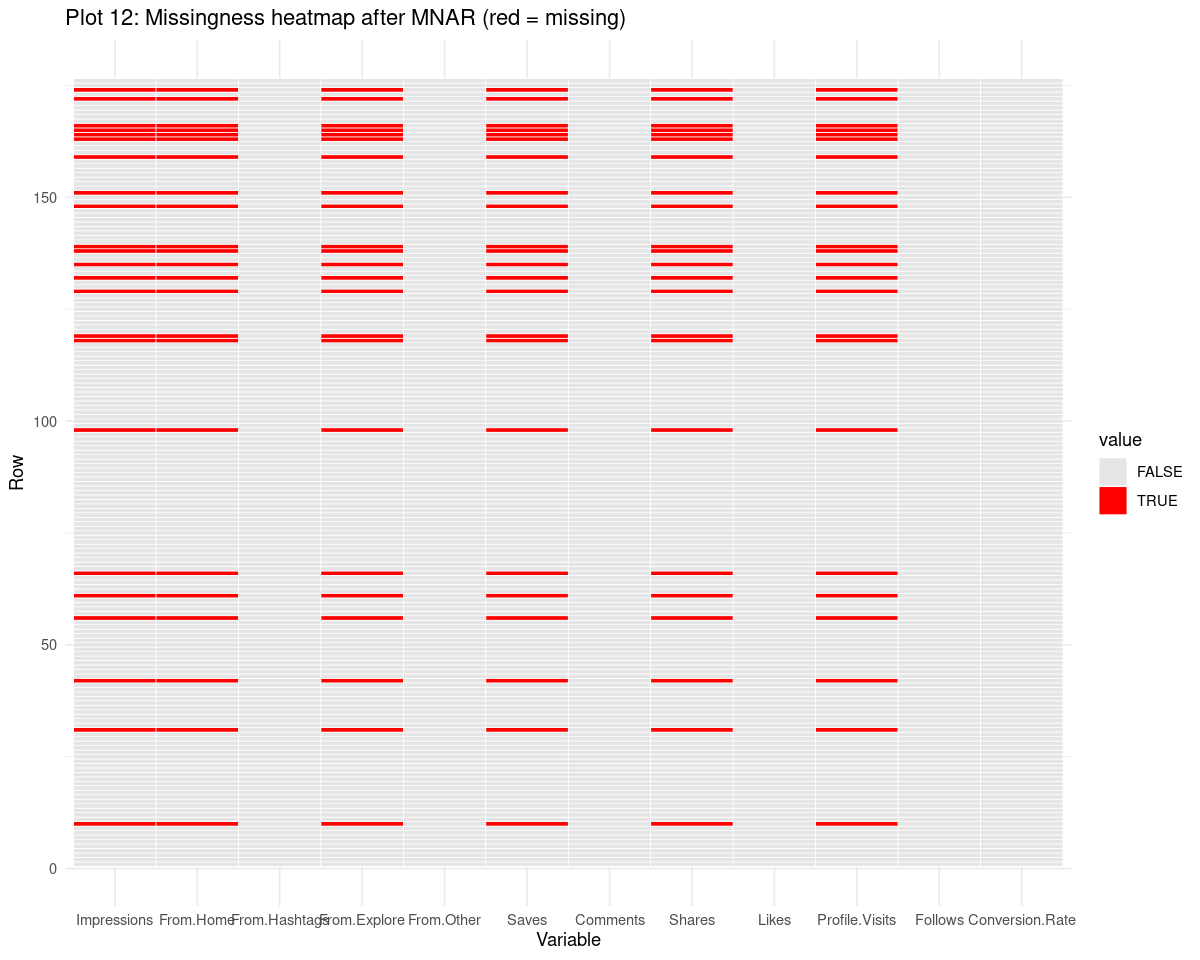

In [34]:
missing_after <- is.na(data_with_missing)
missing_melt_after <- reshape2::melt(missing_after)
missing_melt_after$value <- as.logical(missing_melt_after$value)
p12 <- ggplot(missing_melt_after, aes(x = Var2, y = Var1, fill = value)) +
  geom_tile(color = "white") + scale_fill_manual(values = c("grey90","red")) +
  theme_minimal() + labs(title = "Plot 12: Missingness heatmap after MNAR (red = missing)", x = "Variable", y = "Row")
print(p12); save_plot(p12, "12_missing_heatmap_after_mnar.png")

In [35]:
write.csv(data_with_missing, "Instagram_MNAR_missing.csv", row.names = FALSE)
cat("MNAR dataset saved as Instagram_MNAR_missing.csv\n")


MNAR dataset saved as Instagram_MNAR_missing.csv


### 6.2. Missing Percentage By variable AFTER MNAR

In [36]:
# missing_pct_after <- colMeans(is.na(data_with_missing)) * 100
# p13 <- ggplot(data.frame(variable = names(missing_pct_after), pct = missing_pct_after),
#               aes(x = reorder(variable, -pct), y = pct)) +
#   geom_col(fill = "firebrick") + geom_text(aes(label = paste0(round(pct,1), "%")), vjust = -0.5) +
#   theme_minimal() + theme(axis.text.x = element_text(angle=45, hjust=1)) +
#   labs(title = "Plot 13: Missing % by variable (after MNAR)", x = "Variable", y = "Missing %")
# print(p13); save_plot(p13, "13_missing_pct_after_mnar.png")

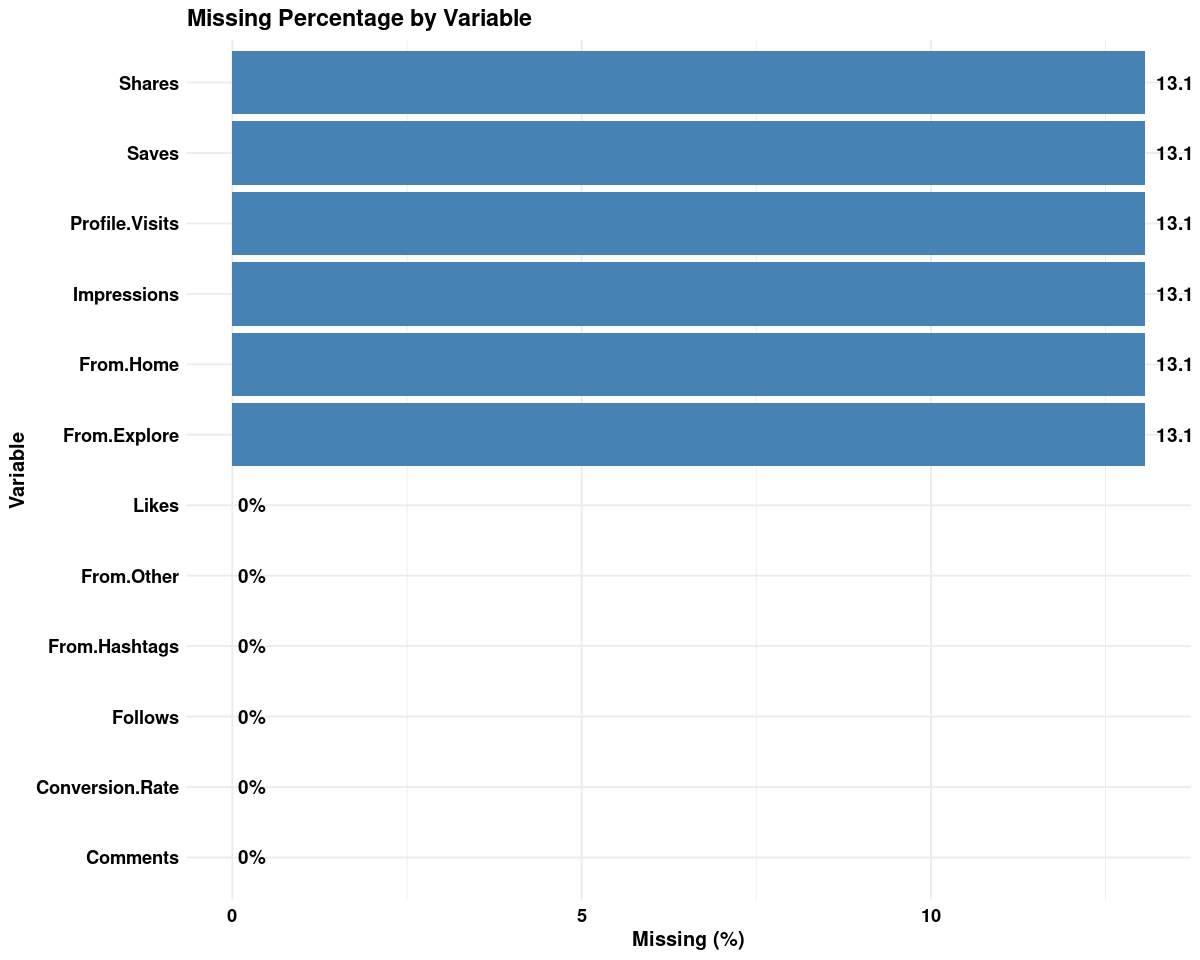

In [37]:
missing_pct_after <- colMeans(is.na(data_with_missing)) * 100
p13 <- ggplot(
  data.frame(variable = names(missing_pct_after),
             pct = missing_pct_after),
  aes(x = reorder(variable, pct), y = pct)
) +
  geom_bar(stat = "identity", fill = "steelblue") +
  geom_text(aes(label = paste0(round(pct, 1), "%")),
            hjust = -0.2, size = 4, color = "black", fontface = "bold") +
  coord_flip() +
  theme_minimal() +
  labs(
    title = "Missing Percentage by Variable",
    x = "Variable",
    y = "Missing (%)"
  ) +
  theme(
    # Improve clarity
    axis.text.x = element_text(color = "black", size = 11, face = "bold"),
    axis.text.y = element_text(color = "black", size = 11, face = "bold"),
    axis.title.x = element_text(color = "black", size = 12, face = "bold"),
    axis.title.y = element_text(color = "black", size = 12, face = "bold"),
    plot.title = element_text(color = "black", size = 14, face = "bold")
  )

print(p13)
save_plot(p13, "13_missing_pct_horizontal_highcontrast.png")


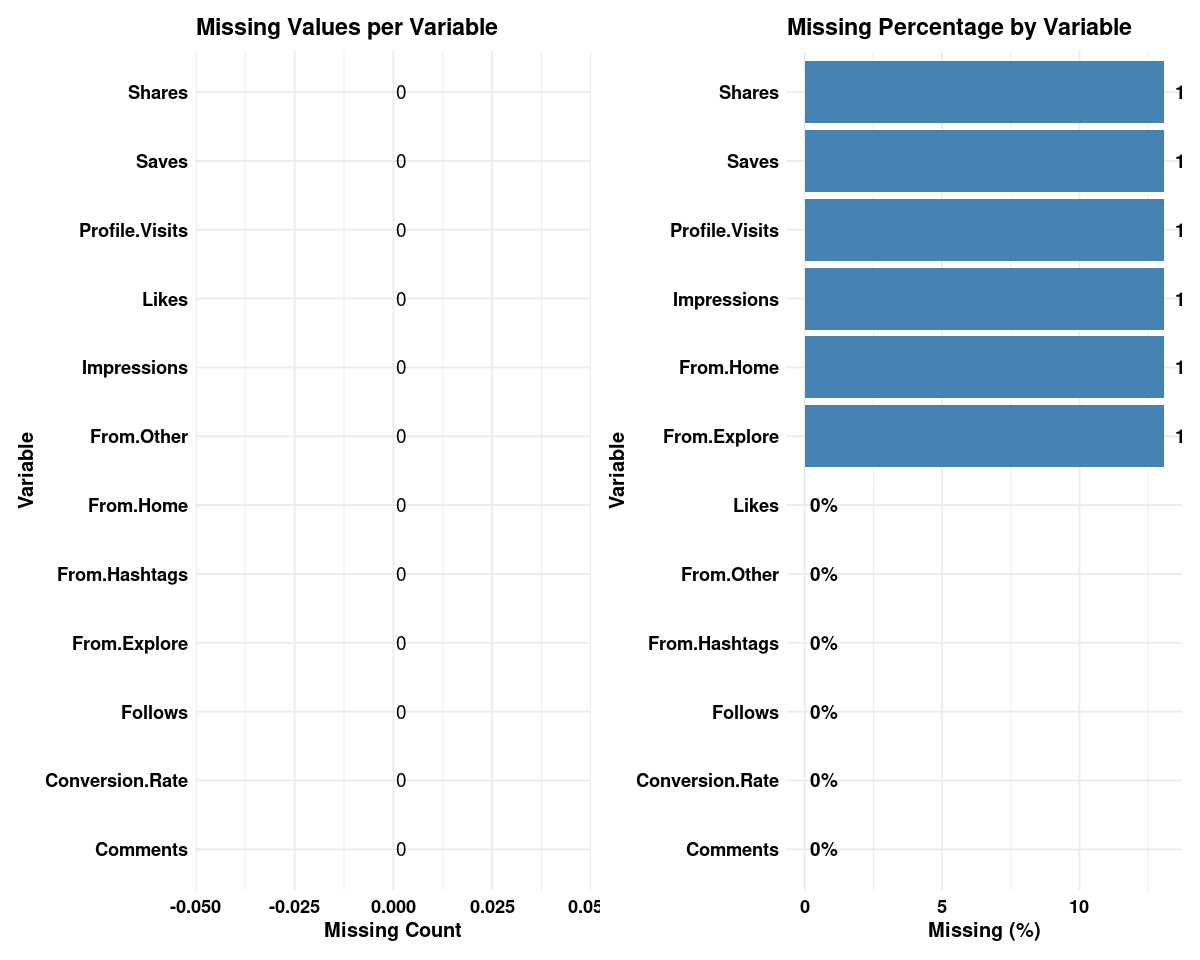

In [38]:
# Add bold axis styling to p10
p10 <- p10 + theme(
  axis.title.x = element_text(face = "bold", size = 12),
  axis.title.y = element_text(face = "bold", size = 12),
  axis.text.x  = element_text(face = "bold", size = 11),
  axis.text.y  = element_text(face = "bold", size = 11)
)

# Add bold axis styling to p13
p13 <- p13 + theme(
  axis.title.x = element_text(face = "bold", size = 12),
  axis.title.y = element_text(face = "bold", size = 12),
  axis.text.x  = element_text(face = "bold", size = 11),
  axis.text.y  = element_text(face = "bold", size = 11)
)

# Combine side by side
library(patchwork)
combined_plot <- p10 + p13 + plot_layout(ncol = 2)
print(combined_plot)


### 6.3. Distribution Comparision 

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


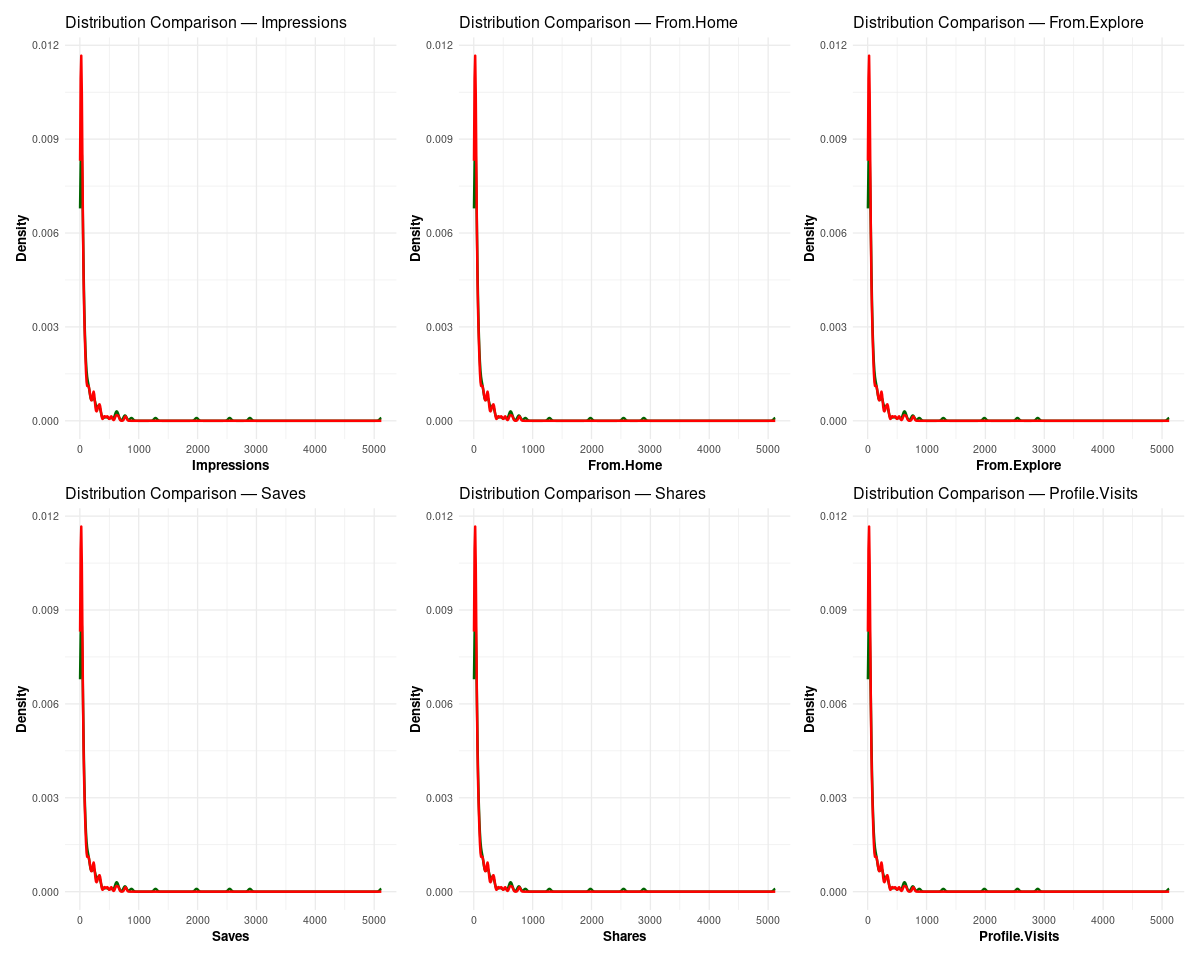

In [39]:
library(ggplot2)
library(patchwork)

plots <- list()
compare_vars <- names(df_num)[desired_idx]
for (v in compare_vars) {
  p <- ggplot() +
    geom_density(aes(x = df_num[[v]]), color = "darkgreen", size = 0.7, na.rm = TRUE) +
    geom_density(aes(x = data_with_missing[[v]]), color = "red", size = 0.7, na.rm = TRUE) +
    labs(
      title = paste0("Distribution Comparison — ", v),
      x = v, y = "Density"
    ) +
    theme_minimal(base_size = 8) +
    theme(
      axis.title.x = element_text(face = "bold"),   # bold x-axis
      axis.title.y = element_text(face = "bold")    # bold y-axis
    )
  
  plots[[v]] <- p
}

# Combine all into grid layout
multi_plot <- wrap_plots(plots, ncol = 3)

multi_plot
ggsave("combined_density_plots.png", multi_plot, width = 12, height = 8, dpi = 300)


### 6.4. Boxplot comparision for impressions

No id variables; using all as measure variables

Warning message:
“Removed 23 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 23 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


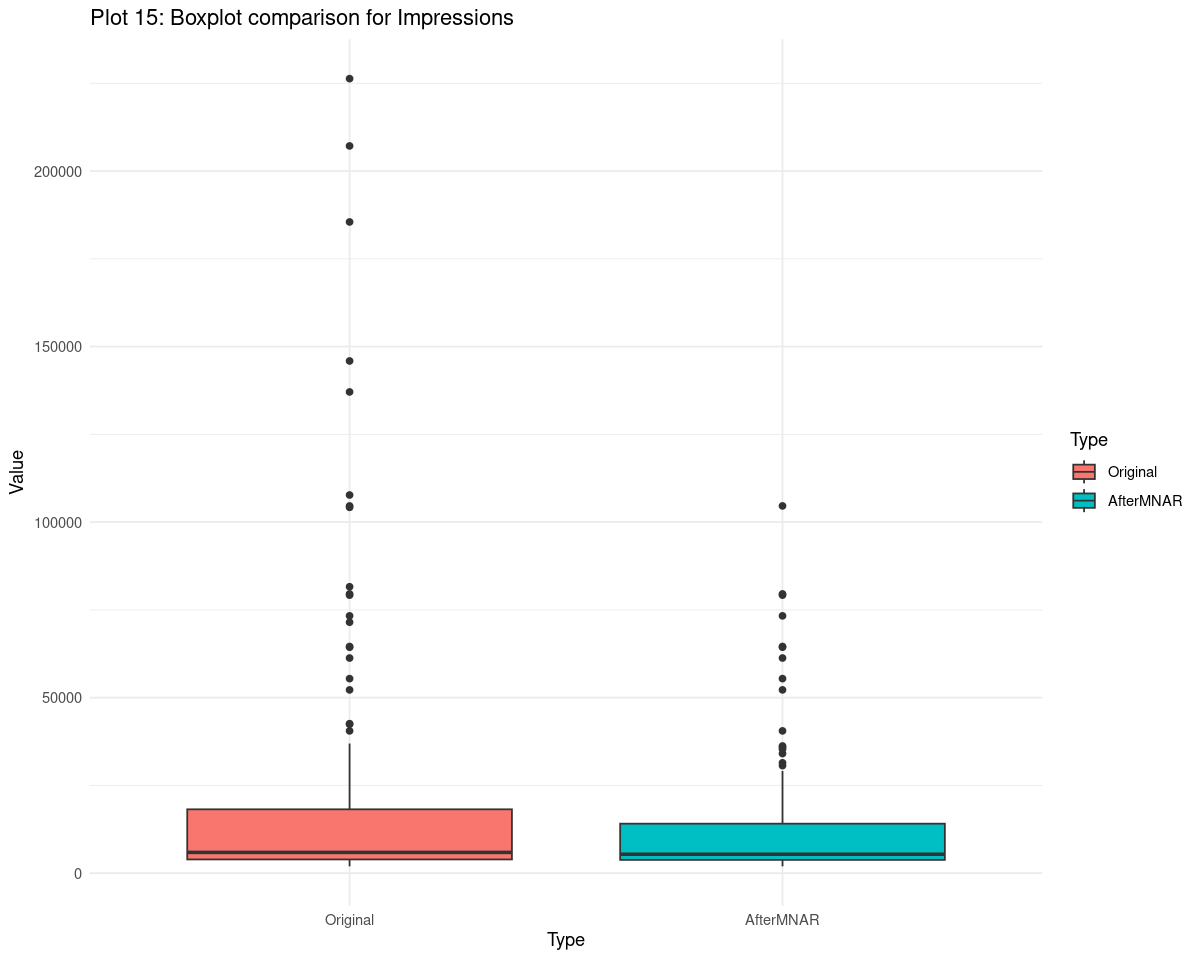

In [40]:
v0 <- compare_vars[1]
if (!is.null(v0)) {
  df_comp <- data.frame(
    Original = df_num[[v0]],
    AfterMNAR = data_with_missing[[v0]]
  )
  df_comp_long <- reshape2::melt(df_comp, variable.name = "Type", value.name = "Value")
  p15 <- ggplot(df_comp_long, aes(x = Type, y = Value, fill = Type)) + geom_boxplot() + theme_minimal() +
    labs(title = paste("Plot 15: Boxplot comparison for", v0))
  print(p15); save_plot(p15, paste0("15_box_comp_", v0, ".png"))
}

### 6.5. Multivariate analysis & classification demo

In [41]:
cat("--- Multivariate analysis & classification demo ---\n")
# PCA on original numeric (for interpretability; use complete-case)
pca_orig_input <- na.omit(df_num)
if (nrow(pca_orig_input) >= 3 && ncol(pca_orig_input) >= 2) {
  pca_orig <- prcomp(pca_orig_input, center=TRUE, scale.=TRUE)
  print(summary(pca_orig))
  # plot PC1 vs PC2 (saved earlier if available)
  png(file.path(plots_dir, "pca_original_pc1_pc2.png"), width=800, height=600)
  plot(pca_orig$x[,1], pca_orig$x[,2], pch=19, main="PCA Original: PC1 vs PC2", xlab="PC1", ylab="PC2")
  dev.off()
  cat("PCA on original data done and saved.\n")
} else {
  cat("Not enough complete data for PCA on original numeric.\n")
}

--- Multivariate analysis & classification demo ---
Importance of components:
                         PC1    PC2     PC3     PC4     PC5     PC6     PC7
Standard deviation     2.747 1.1223 1.00382 0.82668 0.76736 0.59550 0.56240
Proportion of Variance 0.629 0.1050 0.08397 0.05695 0.04907 0.02955 0.02636
Cumulative Proportion  0.629 0.7339 0.81791 0.87486 0.92393 0.95348 0.97984
                           PC8     PC9    PC10    PC11     PC12
Standard deviation     0.44997 0.14424 0.11172 0.07798 0.007085
Proportion of Variance 0.01687 0.00173 0.00104 0.00051 0.000000
Cumulative Proportion  0.99672 0.99845 0.99949 1.00000 1.000000
PCA on original data done and saved.


## 7. Time series analysis

Time series analysis (if date column present)
Detected date-like column: Date 
Trying to parse dates...


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


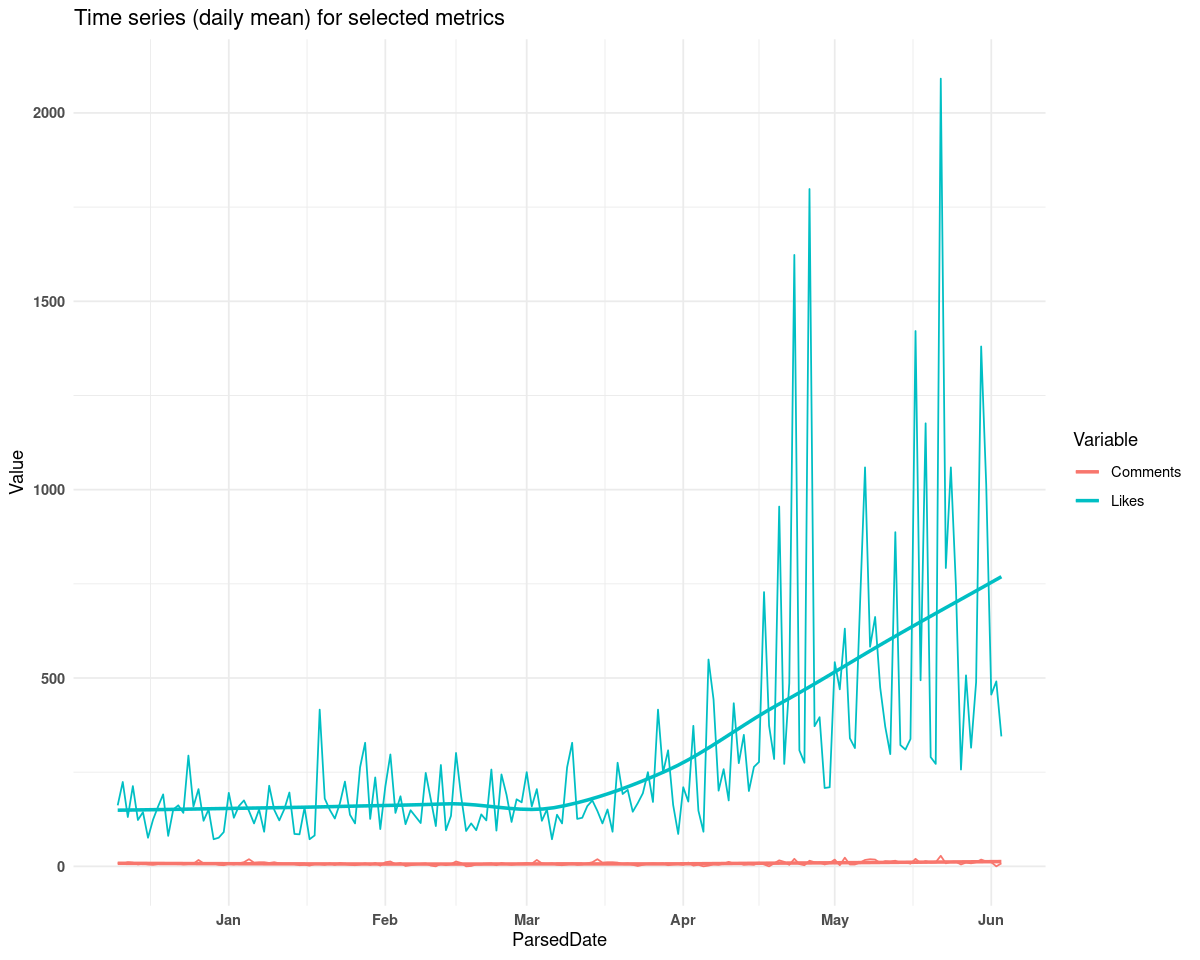

In [42]:
cat("Time series analysis (if date column present)\n")

# Look for a date-like column name
date_col_candidates <- names(df)[str_detect(tolower(names(df)), "date|time|timestamp|posted")]
date_col <- if (length(date_col_candidates) > 0) date_col_candidates[1] else NA

if (!is.na(date_col)) {
  cat("Detected date-like column:", date_col, "\nTrying to parse dates...\n")
  
  parsed <- parse_date_time(df[[date_col]],
                            orders = c("ymd","mdy","dmy","ymd HMS","mdy HMS","dmy HMS"),
                            tz = "UTC", quiet = TRUE)
  
  if (all(is.na(parsed))) {
    cat("Could not parse date column reliably. Skipping time series plots.\n")
  } else {
    df$ParsedDate <- as.Date(parsed)

    ts_vars <- intersect(c("Likes","Comments","Shares","Profile.Visits","Followers"), names(df_num))

    if (length(ts_vars) >= 1) {
      ts_vars_plot <- ts_vars[1:min(2, length(ts_vars))]
      
      df_ts <- df %>%
        filter(!is.na(ParsedDate)) %>%
        group_by(ParsedDate) %>%
        summarise(across(all_of(ts_vars_plot), ~ mean(.x, na.rm = TRUE)), .groups = "drop")
      
      df_ts_long <- pivot_longer(df_ts, cols = -ParsedDate,
                                 names_to = "Variable", values_to = "Value")

      p_ts <- ggplot(df_ts_long, aes(x = ParsedDate, y = Value, color = Variable)) +
        geom_line() +
        geom_smooth(se = FALSE, method = "loess") +
        theme_minimal() +
        labs(title = "Time series (daily mean) for selected metrics") +
        theme(
          axis.text.x = element_text(face = "bold"),
          axis.text.y = element_text(face = "bold")
        )

      print(p_ts)
      save_plot(p_ts, "time_series_selected_metrics.png")

    } else {
      cat("No numeric metrics suitable for time series plots.\n")
    }
  }

} else {
  cat("No date-like column found. Time series step skipped.\n")
}


### 8. REGEX TEXT ANALYSIS

In [43]:
## a) Captions containing the word "love"
love_posts <- df %>% filter(str_detect(clean_caption, "\\blove\\b"))
cat("\nPosts containing the word 'love':\n")
love_posts %>% select(Caption) %>% head()


## b) Extract numbers from Captions
df <- df %>% mutate(numbers_in_caption = str_extract(clean_caption, "\\d+"))
cat("\nExtracted numbers from captions:\n")
df %>% select(Caption, numbers_in_caption) %>% head()


## c) Captions starting with "i"
i_posts <- df %>% filter(str_detect(clean_caption, "^i\\s"))
cat("\nCaptions starting with 'I':\n")
i_posts %>% select(Caption) %>% head()


Posts containing the word 'love':


Caption
<chr>



Extracted numbers from captions:


,Caption,numbers_in_caption
,<chr>,<chr>
1,Here are some of the most important data visualizations that every Financial Data Analyst/Scientist should know.,NA
2,Here are some of the best data science project ideas on healthcare. If you want to become a data science professional in the healthcare domain then you must try to work on these projects.,NA
3,Learn how to train a machine learning model and giving inputs to your trained model to make predictions using Python.,NA
4,Here’s how you can write a Python program to detect whether a sentence is a question or not. The idea here is to find the words that we see in the beginning of a question in the beginning of a sentence.,NA
5,Plotting annotations while visualizing your data is considered good practice to make the graphs self-explanatory. Here is an example of how you can annotate a graph using Python.,NA
6,Here are some of the most important soft skills that every data scientist should have.,NA



Captions starting with 'I':


,Caption
,<chr>
1,"I have been researching Instagram reach for a long time now. Every time I post on my Instagram account, I collect data on how well the post reach after a week. That helps in understanding how Instagram's algorithm is working. Here you will learn how to perform Instagram Reach Analysis and predict the reach of your Instagram posts with machine learning using Python."
2,"I have been researching Instagram reach for a long time now. Every time I post on my Instagram account, I collect data on how well the post reach after a week. That helps in understanding how Instagram's algorithm is working. Here you will learn how to perform Instagram Reach Analysis and predict the reach of your Instagram posts with machine learning using Python."


## 9. SENTIMENTAL ANALYSIS for CAPTIONS

In [44]:
# --- Perform sentiment analysis using syuzhet ---
df$caption_sentiment_score <- get_sentiment(df$clean_caption, method = "syuzhet")

# --- Categorize into Positive / Negative / Neutral ---
df$caption_sentiment_label <- ifelse(df$caption_sentiment_score > 0, "Positive",
                                     ifelse(df$caption_sentiment_score < 0, "Negative", "Neutral"))

# --- Summary counts ---
table(df$caption_sentiment_label)
head(df)


Negative  Neutral Positive 
       4       17      155 

,Date,Impressions,From.Home,From.Hashtags,From.Explore,From.Other,Saves,Comments,Shares,Likes,Profile.Visits,Follows,Conversion.Rate,Caption,Hashtags,clean_caption,ParsedDate,numbers_in_caption,caption_sentiment_score,caption_sentiment_label
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<date>,<chr>,<dbl>,<chr>
1,12/10/2021,3920,2586,1028,619,56,98,9,5,162,35,2,5.714286,Here are some of the most important data visualizations that every Financial Data Analyst/Scientist should know.,#finance #money #business #investing #investment #trading #stockmarket #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,here are some of the most important data visualizations that every financial data analystscientist should know,2021-12-10,NA,0.75,Positive
2,12/11/2021,5394,2727,1838,1174,78,194,7,14,224,48,10,20.833333,Here are some of the best data science project ideas on healthcare. If you want to become a data science professional in the healthcare domain then you must try to work on these projects.,#healthcare #health #covid #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,here are some of the best data science project ideas on healthcare if you want to become a data science professional in the healthcare domain then you must try to work on these projects,2021-12-11,NA,1.55,Positive
3,12/12/2021,4021,2085,1188,0,533,41,11,1,131,62,12,19.354839,Learn how to train a machine learning model and giving inputs to your trained model to make predictions using Python.,#data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #deeplearning #machinelearningprojects #datascienceprojects #amankharwal #thecleverprogrammer #machinelearningmodels,learn how to train a machine learning model and giving inputs to your trained model to make predictions using python,2021-12-12,NA,2.00,Positive
4,12/13/2021,4528,2700,621,932,73,172,10,7,213,23,8,34.782609,Here’s how you can write a Python program to detect whether a sentence is a question or not. The idea here is to find the words that we see in the beginning of a question in the beginning of a sentence.,#python #pythonprogramming #pythonprojects #pythoncode #pythonlearning #pythondeveloper #pythoncoding #pythonprogrammer #amankharwal #thecleverprogrammer #pythonprojects,heres how you can write a python program to detect whether a sentence is a question or not the idea here is to find the words that we see in the beginning of a question in the beginning of a sentence,2021-12-13,NA,0.10,Positive
5,12/14/2021,2518,1704,255,279,37,96,5,4,123,8,0,0.000000,Plotting annotations while visualizing your data is considered good practice to make the graphs self-explanatory. Here is an example of how you can annotate a graph using Python.,#datavisualization #datascience #data #dataanalytics #machinelearning #dataanalysis #artificialintelligence #python #datascientist #bigdata #deeplearning #dataviz #ai #analytics #technology #dataanalyst #programming #pythonprogramming #statistics #coding #businessintelligence #datamining #tech #business #computerscience #tableau #database #thecleverprogrammer #amankharwal,plotting annotations while visualizing your data is considered good practice to make the graphs selfexplanatory here is an example of how you can annotate a graph using python,2021-12-14,NA,1.15,Positive
6,12/15/2021,3884,2046,1214,329,43,74,7,10,144,9,2,22.222222,Here are some of the most important soft skills that every data scientist should have.,#data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming 

### 9.1. bar plot of sentimental analysis for CAPTIONS

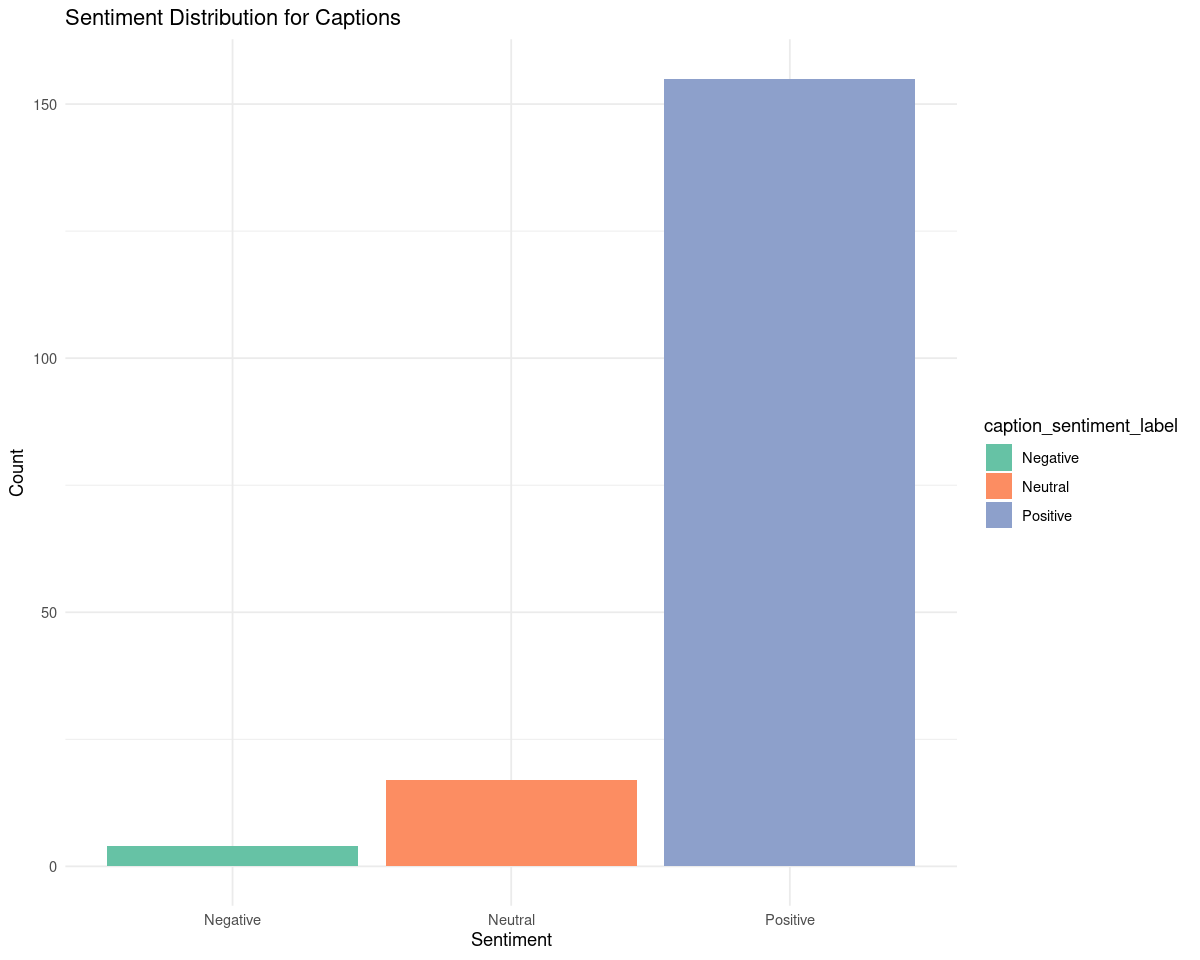

In [45]:
# --- Visualization: Bar Plot ---
ggplot(df, aes(x = caption_sentiment_label, fill = caption_sentiment_label)) +
  geom_bar() +
  scale_fill_brewer(palette = "Set2") +
  labs(title = "Sentiment Distribution for Captions", x = "Sentiment", y = "Count") +
  theme_minimal()

### 9.2.   Visualization: Pie Chart 

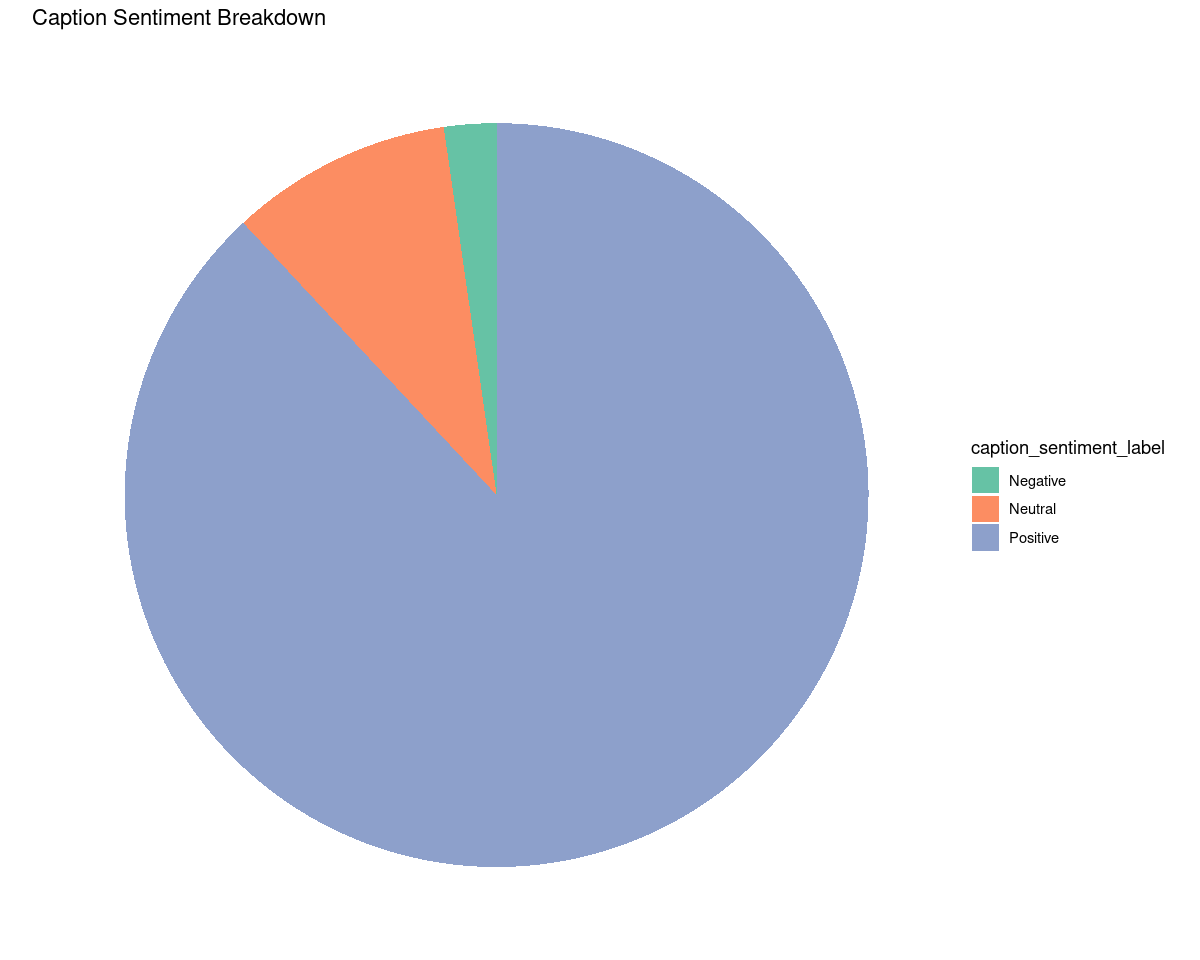

In [46]:
# --- Visualization: Pie Chart ---
caption_counts <- df %>% count(caption_sentiment_label)
ggplot(caption_counts, aes(x = "", y = n, fill = caption_sentiment_label)) +
  geom_col(width = 1) +
  coord_polar(theta = "y") +
  labs(title = "Caption Sentiment Breakdown") +
  theme_void() +
  scale_fill_brewer(palette = "Set2")

### 9.3. CAPTIONS - SENTIMENT PLOT — POSITIVE / NEGATIVE


Attaching package: ‘readr’


The following object is masked from ‘package:scales’:

    col_factor


Rows: 176 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): Date, Caption, Hashtags
dbl (12): Impressions, From Home, From Hashtags, From Explore, From Other, S...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


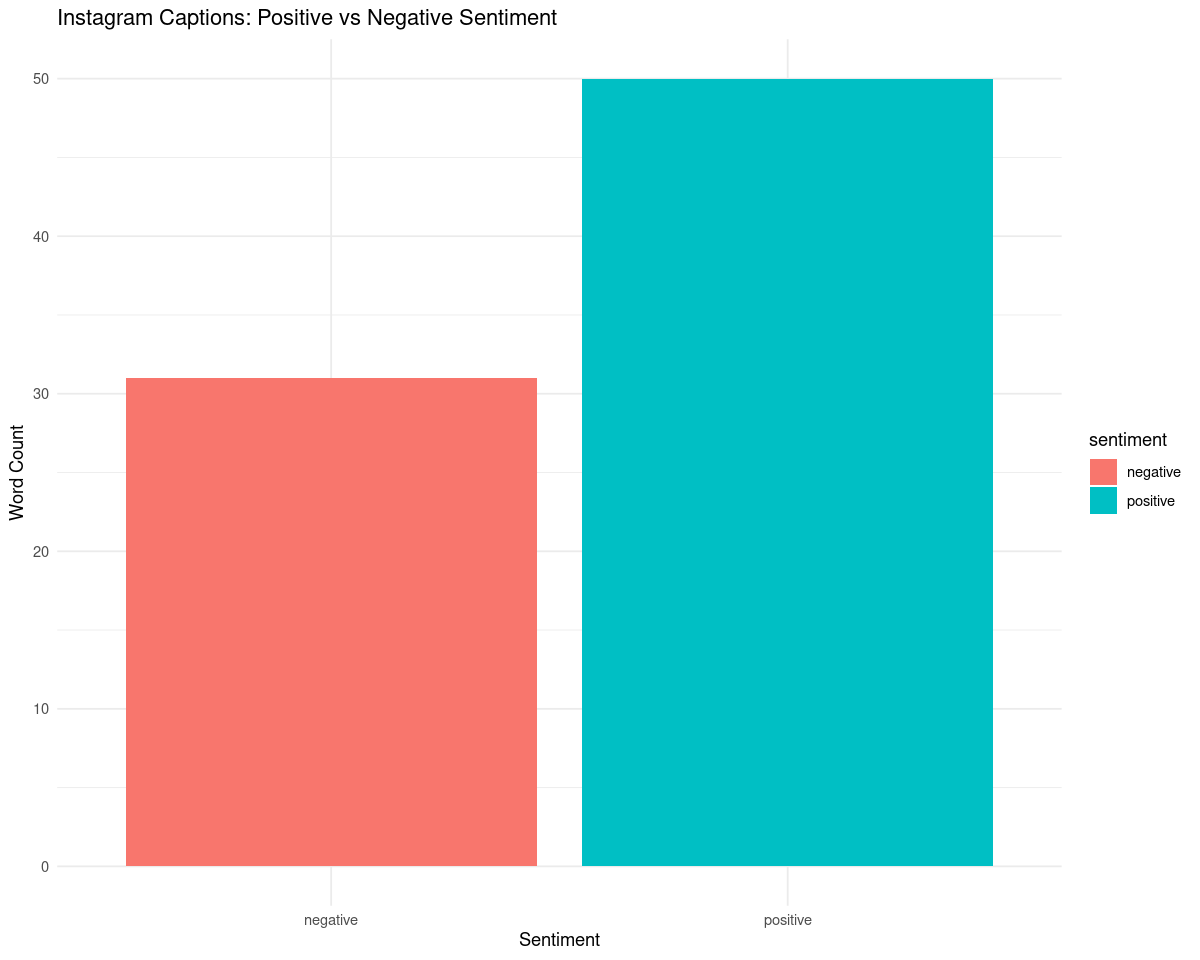

In [47]:
library(readr)
library(dplyr)
library(stringr)
library(tidytext)
library(ggplot2)

instagram_data <- read_csv("Instagram-data_CURRENT.csv")

df <- instagram_data %>%
  mutate(id = row_number()) %>%
  select(id, Caption) %>%
  rename(text = Caption)
df_clean <- df %>%
  mutate(text = str_to_lower(text),
         text = str_replace_all(text, "[^a-z ]", " "),
         text = str_squish(text))

tokens <- df_clean %>%
  unnest_tokens(word, text) %>%
  anti_join(stop_words, by = "word") %>%
  filter(nchar(word) > 2)
sentiment_counts <- tokens %>%
  inner_join(get_sentiments("bing"), by = "word") %>%
  count(sentiment)
ggplot(sentiment_counts, aes(x = sentiment, y = n, fill = sentiment)) +
  geom_col() +
  labs(title = "Instagram Captions: Positive vs Negative Sentiment",
       x = "Sentiment", y = "Word Count") +
  theme_minimal()

# 10. SENTIMENT ANALYSIS: HASHTAGS

In [48]:
# =========================================================
# LOAD DATA
# =========================================================
df <- read_csv("Instagram-data_CURRENT.csv", show_col_types = FALSE)

# =========================================================
# CLEANING FUNCTION FOR HASHTAGS
# =========================================================
clean_hashtags <- function(text){
  if(is.na(text) || text=="") return("")
  text <- tolower(text)
  text <- gsub("#", "", text)                    # remove #
  text <- gsub("http\\S+|www\\S+", "", text)     # remove URLs
  text <- gsub("[^[:alnum:]\\s]", " ", text)     # remove punctuation
  text <- gsub("\\s+", " ", text)                # remove extra spaces
  trimws(text)
}

# =========================================================
# CLEAN HASHTAGS
# =========================================================
df$clean_hashtags <- sapply(df$Hashtags, clean_hashtags)

# =========================================================
# SENTIMENT ANALYSIS (HASHTAGS ONLY)
# =========================================================
df$hashtag_sentiment_score <- get_sentiment(df$clean_hashtags, method = "syuzhet")

df$hashtag_sentiment_label <- ifelse(
  df$hashtag_sentiment_score > 0, "Positive",
  ifelse(df$hashtag_sentiment_score < 0, "Negative", "Neutral")
)

# =========================================================
# SUMMARY TABLE
# =========================================================
hashtag_summary <- df %>%
  count(hashtag_sentiment_label) %>%
  mutate(Percent = round(n / sum(n) * 100, 2))

# Show summary
hashtag_summary

hashtag_sentiment_label,n,Percent
<chr>,<int>,<dbl>
Negative,9,5.11
Neutral,141,80.11
Positive,26,14.77


In [49]:
# --- Perform sentiment analysis on hashtags ---
df$hashtag_sentiment_score <- get_sentiment(df$clean_hashtags, method = "syuzhet")

# --- Categorize into Positive / Negative / Neutral ---
df$hashtag_sentiment_label <- ifelse(df$hashtag_sentiment_score > 0, "Positive",
                                     ifelse(df$hashtag_sentiment_score < 0, "Negative", "Neutral"))

# --- Summary counts ---
table(df$hashtag_sentiment_label)
head(df)


Negative  Neutral Positive 
       9      141       26 

Date,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Conversion Rate,Caption,Hashtags,clean_hashtags,hashtag_sentiment_score,hashtag_sentiment_label
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>
12/10/2021,3920,2586,1028,619,56,98,9,5,162,35,2,5.714286,Here are some of the most important data visualizations that every Financial Data Analyst/Scientist should know.,#finance #money #business #investing #investment #trading #stockmarket #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,finance money business investing investment trading stockmarket data datascience dataanalysis dataanalytics datascientist machinelearning python pythonprogramming pythonprojects pythoncode artificialintelligence ai dataanalyst amankharwal thecleverprogrammer,0.6,Positive
12/11/2021,5394,2727,1838,1174,78,194,7,14,224,48,10,20.833333,Here are some of the best data science project ideas on healthcare. If you want to become a data science professional in the healthcare domain then you must try to work on these projects.,#healthcare #health #covid #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,healthcare health covid data datascience dataanalysis dataanalytics datascientist machinelearning python pythonprogramming pythonprojects pythoncode artificialintelligence ai dataanalyst amankharwal thecleverprogrammer,0.0,Neutral
12/12/2021,4021,2085,1188,0,533,41,11,1,131,62,12,19.354839,Learn how to train a machine learning model and giving inputs to your trained model to make predictions using Python.,#data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #deeplearning #machinelearningprojects #datascienceprojects #amankharwal #thecleverprogrammer #machinelearningmodels,data datascience dataanalysis dataanalytics datascientist machinelearning python pythonprogramming pythonprojects pythoncode artificialintelligence ai deeplearning machinelearningprojects datascienceprojects amankharwal thecleverprogrammer machinelearningmodels,0.0,Neutral
12/13/2021,4528,2700,621,932,73,172,10,7,213,23,8,34.782609,Here’s how you can write a Python program to detect whether a sentence is a question or not. The idea here is to find the words that we see in the beginning of a question in the beginning of a sentence.,#python #pythonprogramming #pythonprojects #pythoncode #pythonlearning #pythondeveloper #pythoncoding #pythonprogrammer #amankharwal #thecleverprogrammer #pythonprojects,python pythonprogramming pythonprojects pythoncode pythonlearning pythondeveloper pythoncoding pythonprogrammer amankharwal thecleverprogrammer pythonprojects,0.0,Neutral
12/14/2021,2518,1704,255,279,37,96,5,4,123,8,0,0.000000,Plotting annotations while visualizing your data is considered good practice to make the graphs self-explanatory. Here is an example of how you can annotate a graph using Python.,#datavisualization #datascience #data #dataanalytics #machinelearning #dataanalysis #artificialintelligence #python #datascientist #bigdata #deeplearning #dataviz #ai #analytics #technology #dataanalyst #programming #pythonprogramming #statistics #coding #businessintelligence #datamining #tech #business #computerscience #tableau #database #thecleverprogrammer #amankharwal,datavisualization datascience data dataanalytics machinelearning dataanalysis artificialintelligence python datascientist bigdata deeplearning dataviz ai analytics technology dataanalyst programming pythonprogramming statistics coding businessintelligence datamining tech business computersc

### 10.1. Visualization: Bar Plot - hashtags

Warning message:
“Unknown palette: "Blue"”


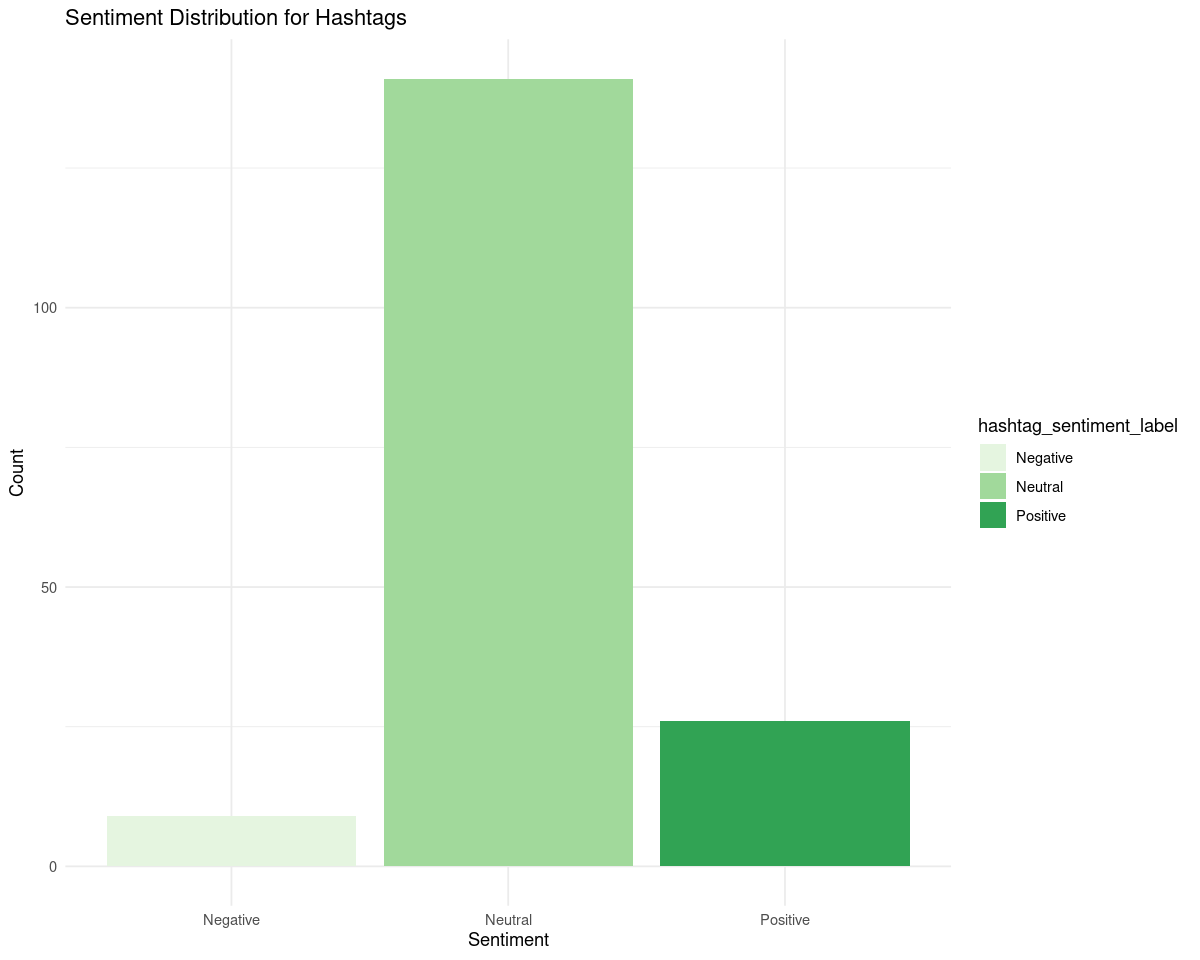

In [50]:
ggplot(df, aes(x=hashtag_sentiment_label, fill=hashtag_sentiment_label)) +
  geom_bar() +
  scale_fill_brewer(palette="Blue") +
  labs(title="Sentiment Distribution for Hashtags", x="Sentiment", y="Count") +
  theme_minimal()

### 10.2. Visualization: Pie Chart

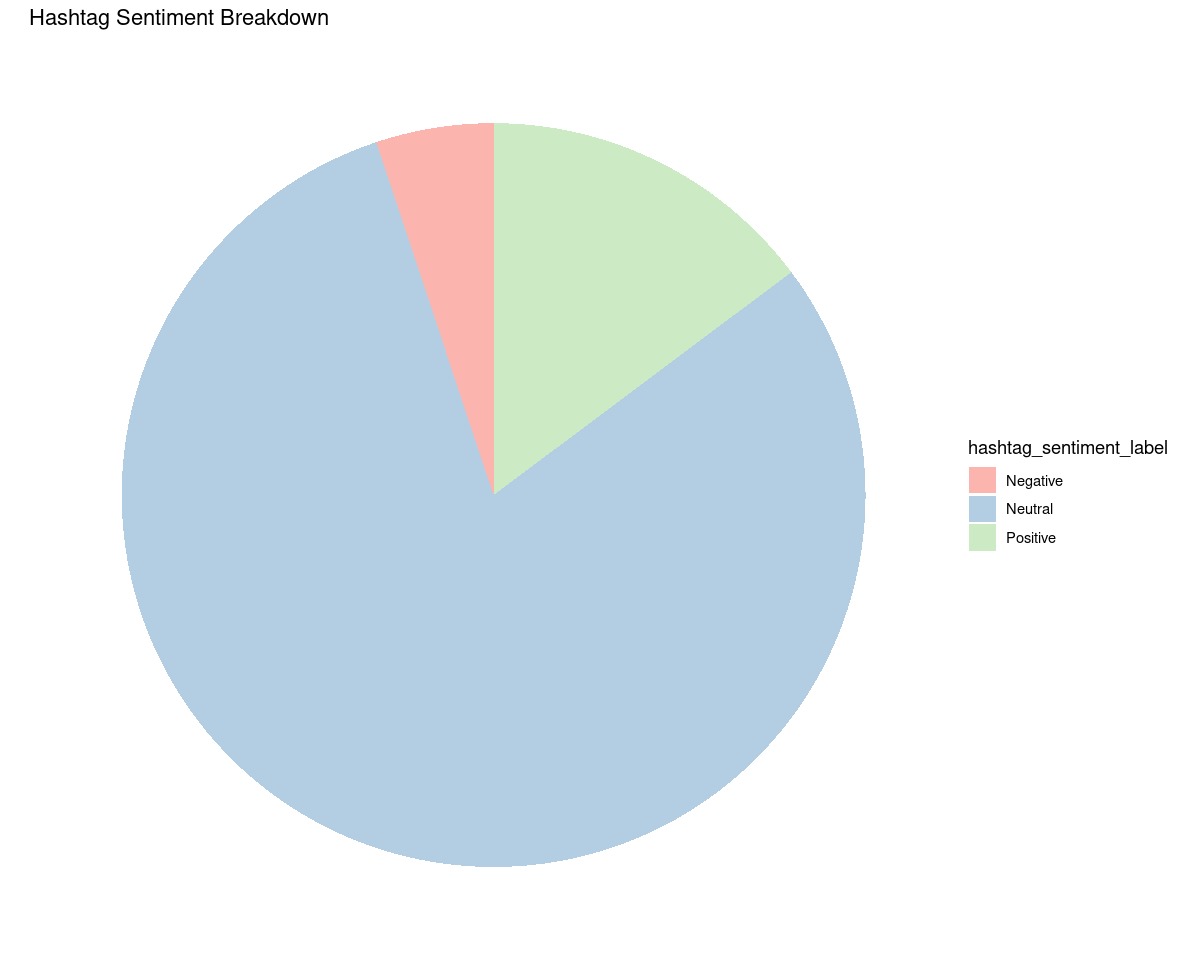

In [51]:
# Count hashtags by sentiment
hashtag_counts <- df %>%
  count(hashtag_sentiment_label)

# Pie chart
ggplot(hashtag_counts, aes(x = "", y = n, fill = hashtag_sentiment_label)) +
  geom_col(width = 1) +
  coord_polar(theta = "y") +
  labs(title = "Hashtag Sentiment Breakdown") +
  theme_void() +
  scale_fill_brewer(palette = "Pastel1")  # You can change palette

### 10.3. POSITIVE vs NEGATIVE SENTIMENT - hashtags

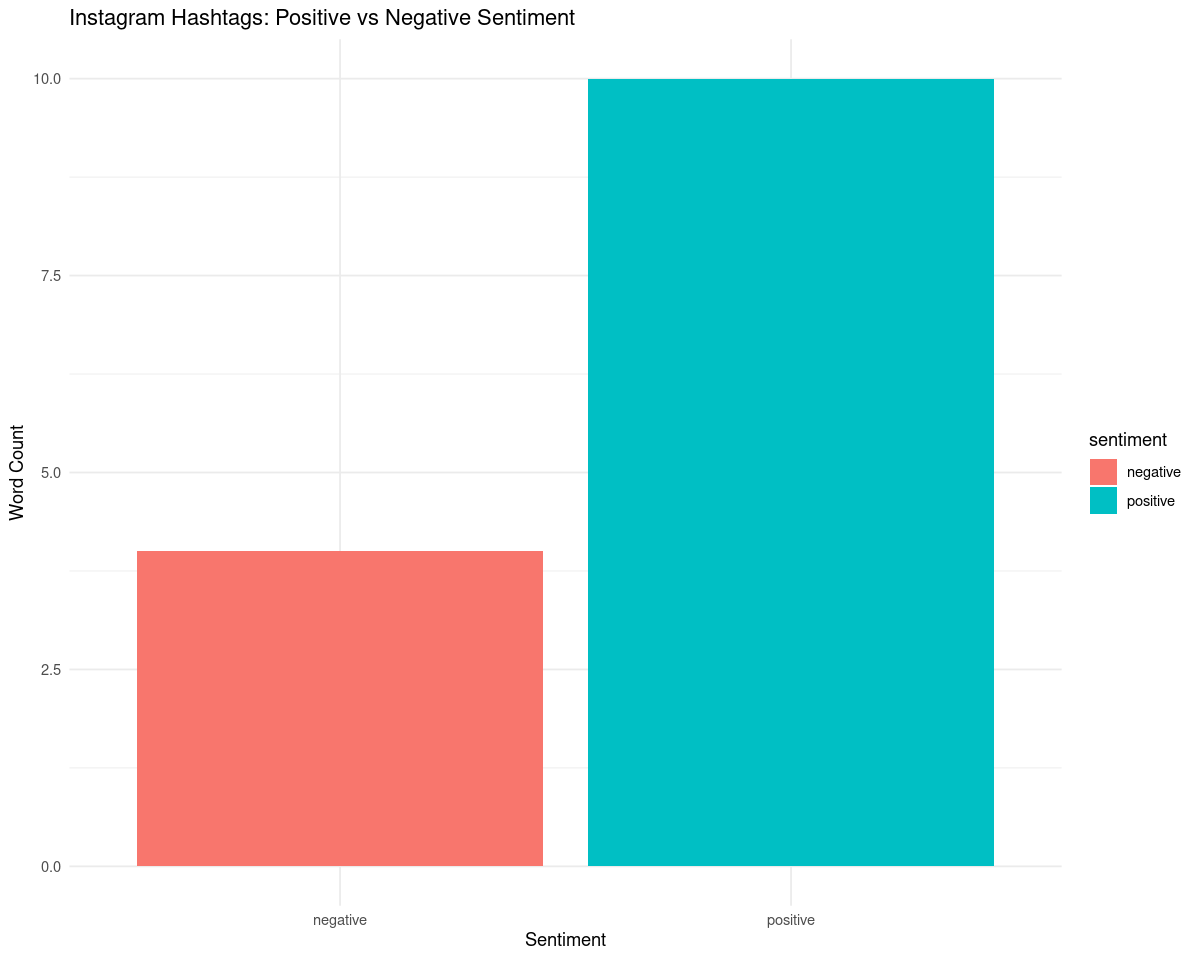

In [52]:
library(dplyr)
library(stringr)
library(tidytext)
library(ggplot2)

# --------------------------
# 1. FIX COLUMN NAME + CLEAN
# --------------------------
df_hashtags <- instagram_data %>%
  mutate(id = row_number()) %>%
  select(id, Hashtags) %>%        # <-- USE YOUR EXACT COLUMN NAME
  rename(text = Hashtags)

df_hashtags_clean <- df_hashtags %>%
  mutate(text = tolower(text)) %>%
  mutate(text = str_replace_all(text, "#", " ")) %>%             # remove hashtag symbol
  mutate(text = str_replace_all(text, "http\\S+|www\\S+", " ")) %>%  # remove URLs
  mutate(text = str_replace_all(text, "[^a-z ]", " ")) %>%       # keep letters only
  mutate(text = str_squish(text))

# --------------------------
# 2. TOKENIZE
# --------------------------
hashtag_tokens <- df_hashtags_clean %>%
  unnest_tokens(word, text) %>%
  anti_join(stop_words, by = "word") %>%   # remove common stopwords
  filter(nchar(word) > 2)                   # remove tiny words

# --------------------------
# 3. SENTIMENT USING BING
# --------------------------
hashtag_sentiment_counts <- hashtag_tokens %>%
  inner_join(get_sentiments("bing"), by = "word") %>%
  count(sentiment)

# --------------------------
# 4. PLOT RESULTS
# --------------------------
ggplot(hashtag_sentiment_counts, aes(x = sentiment, y = n, fill = sentiment)) +
  geom_col() +
  labs(
    title = "Instagram Hashtags: Positive vs Negative Sentiment",
    x = "Sentiment",
    y = "Word Count"
  ) +
  theme_minimal()

## 11. Topic Modeling Using Lexicons

In [56]:
df <- "Instagram-data_CURRENT.csv"

instagram_data <- read_csv(df)

# Ensure column names are standard
colnames(instagram_data) <- tolower(colnames(instagram_data))

# Expecting column 'caption'
if (!"caption" %in% colnames(instagram_data)) {
  stop("❌ Column 'caption' not found in your CSV. Please verify the file.")
}

###############################################################################
# STEP 2: CLEAN TEXT + REMOVE STOPWORDS
###############################################################################
data("stop_words")

cleaned_words <- instagram_data %>%
  mutate(id = row_number()) %>%
  unnest_tokens(word, caption) %>%
  anti_join(stop_words, by = "word") %>%       # Remove: the, and, of, to...
  filter(!str_detect(word, "^[0-9]+$")) %>%    # Remove pure numbers
  filter(nchar(word) > 2)                      # Remove 1-2 letter junk

###############################################################################
# STEP 3: DEFINE PROFESSION-RELATED LEXICONS
###############################################################################
profession_lexicon <- list(
  healthcare = c("doctor","nurse","medical","hospital","clinic",
                 "healthcare","therapist","mental","surgery","pharmacy"),
  finance = c("finance","financial","analyst","investment","stocks",
              "banking","economics","trading","portfolio"),
  tech = c("data","scientist","engineering","developer","ai","machine",
           "learning","cloud","software","programmer","coding","analyst"),
  business = c("manager","marketing","sales","operations","leadership",
               "consultant","startup","entrepreneur")
)                         

Rows: 176 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): Date, Caption, Hashtags
dbl (12): Impressions, From Home, From Hashtags, From Explore, From Other, S...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


### 11.1. ASSIGN ASPECT (PROFESSION CATEGORY)

In [57]:
cleaned_words <- cleaned_words %>%
  rowwise() %>%
  mutate(
    profession_category = list(
      names(profession_lexicon)[
        map_lgl(profession_lexicon, ~ word %in% .x)
      ]
    )
  ) %>%
  ungroup()

# Expand rows where multiple categories match
profession_expanded <- cleaned_words %>%
  unnest(profession_category)
head(profession_expanded)

date,impressions,from home,from hashtags,from explore,from other,saves,comments,shares,likes,profile visits,follows,conversion rate,hashtags,id,word,profession_category
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>
12/10/2021,3920,2586,1028,619,56,98,9,5,162,35,2,5.714286,#finance #money #business #investing #investment #trading #stockmarket #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,1,data,tech
12/10/2021,3920,2586,1028,619,56,98,9,5,162,35,2,5.714286,#finance #money #business #investing #investment #trading #stockmarket #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,1,financial,finance
12/10/2021,3920,2586,1028,619,56,98,9,5,162,35,2,5.714286,#finance #money #business #investing #investment #trading #stockmarket #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,1,data,tech
12/10/2021,3920,2586,1028,619,56,98,9,5,162,35,2,5.714286,#finance #money #business #investing #investment #trading #stockmarket #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,1,analyst,finance
12/10/2021,3920,2586,1028,619,56,98,9,5,162,35,2,5.714286,#finance #money #business #investing #investment #trading #stockmarket #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,1,analyst,tech
12/10/2021,3920,2586,1028,619,56,98,9,5,162,35,2,5.714286,#finance #money #business #investing #investment #trading #stockmarket #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,1,scientist,tech


###  11.2. CREATE “PROFESSION SCORE

In [58]:
# Score = number of profession words per caption
profession_score <- profession_expanded %>%
  group_by(id) %>%
  summarise(profession_score = n())

# merge back to data
instagram_scored <- instagram_data %>%
  mutate(id = row_number()) %>%
  left_join(profession_score, by = "id") %>%
  mutate(profession_score = replace_na(profession_score, 0))
head(instagram_scored)


date,impressions,from home,from hashtags,from explore,from other,saves,comments,shares,likes,profile visits,follows,conversion rate,caption,hashtags,id,profession_score
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<int>,<int>
12/10/2021,3920,2586,1028,619,56,98,9,5,162,35,2,5.714286,Here are some of the most important data visualizations that every Financial Data Analyst/Scientist should know.,#finance #money #business #investing #investment #trading #stockmarket #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,1,6
12/11/2021,5394,2727,1838,1174,78,194,7,14,224,48,10,20.833333,Here are some of the best data science project ideas on healthcare. If you want to become a data science professional in the healthcare domain then you must try to work on these projects.,#healthcare #health #covid #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,2,4
12/12/2021,4021,2085,1188,0,533,41,11,1,131,62,12,19.354839,Learn how to train a machine learning model and giving inputs to your trained model to make predictions using Python.,#data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #deeplearning #machinelearningprojects #datascienceprojects #amankharwal #thecleverprogrammer #machinelearningmodels,3,2
12/13/2021,4528,2700,621,932,73,172,10,7,213,23,8,34.782609,Here’s how you can write a Python program to detect whether a sentence is a question or not. The idea here is to find the words that we see in the beginning of a question in the beginning of a sentence.,#python #pythonprogramming #pythonprojects #pythoncode #pythonlearning #pythondeveloper #pythoncoding #pythonprogrammer #amankharwal #thecleverprogrammer #pythonprojects,4,0
12/14/2021,2518,1704,255,279,37,96,5,4,123,8,0,0.000000,Plotting annotations while visualizing your data is considered good practice to make the graphs self-explanatory. Here is an example of how you can annotate a graph using Python.,#datavisualization #datascience #data #dataanalytics #machinelearning #dataanalysis #artificialintelligence #python #datascientist #bigdata #deeplearning #dataviz #ai #analytics #technology #dataanalyst #programming #pythonprogramming #statistics #coding #businessintelligence #datamining #tech #business #computerscience #tableau #database #thecleverprogrammer #amankharwal,5,1
12/15/2021,3884,2046,1214,329,43,74,7,10,144,9,2,22.222222,Here are some of the most important soft skills that every data scientist should have.,#data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #deeplearning #algorithm #algorithms #machinelearningalgorithms #ml #amankharwal #thecleverprogrammer #softskills,6,2


### 11.3. PLOT PROFESSION CATEGORY FREQUENCY

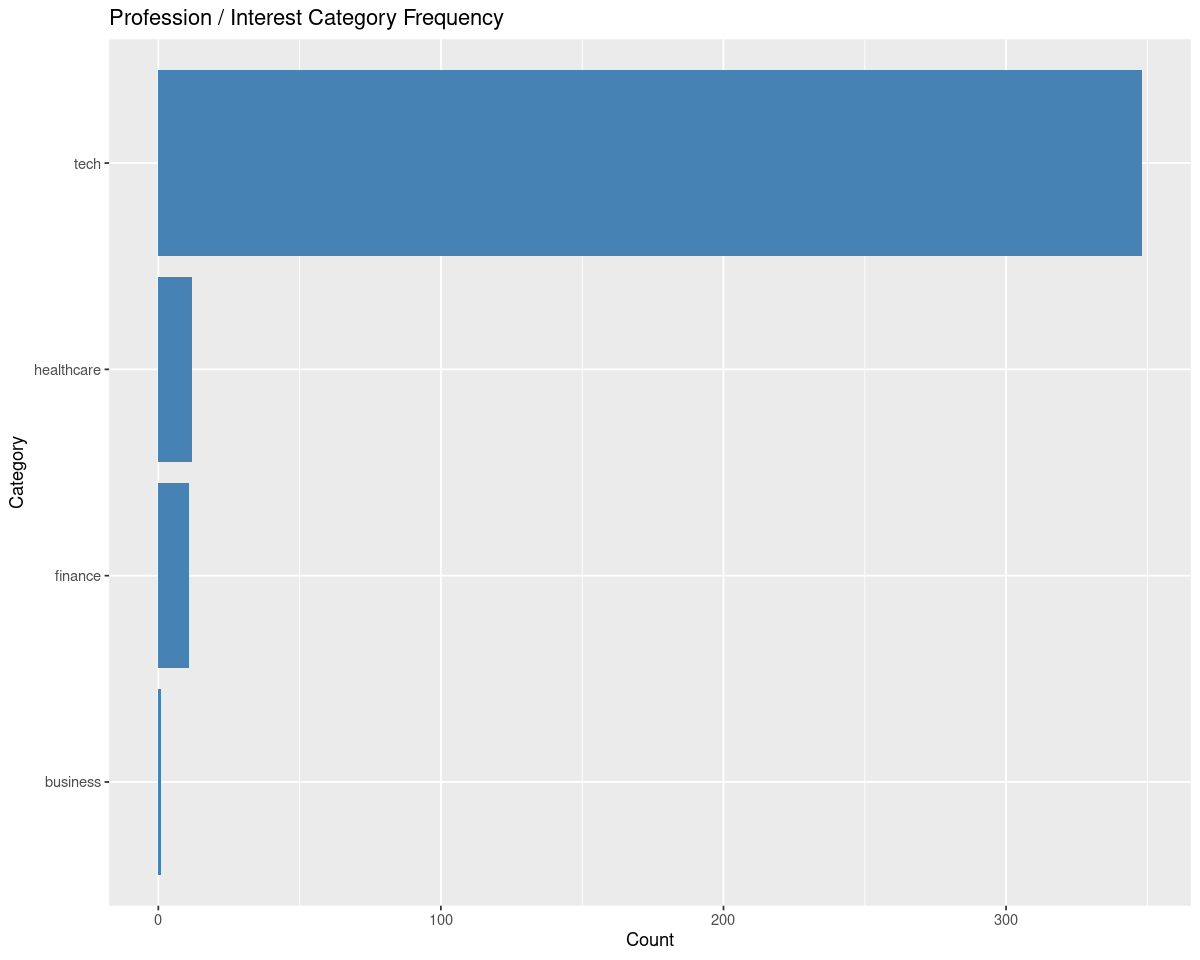

In [59]:
profession_count <- profession_expanded %>%
  count(profession_category, sort = TRUE)

ggplot(profession_count, aes(x = reorder(profession_category, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(title = "Profession / Interest Category Frequency",
       x = "Category", y = "Count")

## 12.  Aspect-Based Sentiment Analysis of Instagram Captions

In [60]:
df <- "Instagram-data_CURRENT.csv"

if (!file.exists(df)) {
  stop("❌ File not found. Please place 'Instagram-data_CURRENT.csv' in working directory.")
}

instagram_data <- read_csv(df)
colnames(instagram_data) <- tolower(colnames(instagram_data))

if (!"caption" %in% colnames(instagram_data)) {
  stop("❌ Column 'caption' not found in CSV.")
}

instagram_data <- instagram_data %>% mutate(id = row_number())

Rows: 176 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): Date, Caption, Hashtags
dbl (12): Impressions, From Home, From Hashtags, From Explore, From Other, S...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [61]:
# STEP 2: CLEAN TEXT + REMOVE STOPWORDS

data("stop_words")

clean_words <- instagram_data %>%
  unnest_tokens(word, caption) %>%
  anti_join(stop_words, by = "word") %>%  
  filter(!str_detect(word, "^[0-9]+$")) %>%   
  filter(nchar(word) > 2)


# STEP 3: PROFESSIONAL ASPECT LEXICONS (TOPIC-BASED)
aspect_lexicon <- list(
  healthcare = c("doctor","nurse","medical","hospital","clinic","health",
                 "healthcare","lab","research","therapy","mental","pharmacy"),
  
  finance = c("finance","financial","bank","investment","stocks","analyst",
              "trading","economics","money","wealth","portfolio","market"),
  
  technology = c("data","scientist","developer","ai","machine","learning",
                 "software","hardware","cloud","engineering","algorithm"),
  
  business = c("manager","marketing","sales","strategy","operations",
               "startup","entrepreneur","consultant","leadership")
)        

### 12.1. Map Words to Profession Categories (ABSA STYLE)

In [62]:
clean_words <- clean_words %>%
  rowwise() %>%
  mutate(
    aspect = list(
      names(aspect_lexicon)[
        map_lgl(aspect_lexicon, ~ word %in% .x)
      ]
    )
  ) %>%
  ungroup()

aspect_words <- clean_words %>% unnest(aspect)
head(aspect_words)

date,impressions,from home,from hashtags,from explore,from other,saves,comments,shares,likes,profile visits,follows,conversion rate,hashtags,id,word,aspect
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>
12/10/2021,3920,2586,1028,619,56,98,9,5,162,35,2,5.714286,#finance #money #business #investing #investment #trading #stockmarket #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,1,data,technology
12/10/2021,3920,2586,1028,619,56,98,9,5,162,35,2,5.714286,#finance #money #business #investing #investment #trading #stockmarket #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,1,financial,finance
12/10/2021,3920,2586,1028,619,56,98,9,5,162,35,2,5.714286,#finance #money #business #investing #investment #trading #stockmarket #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,1,data,technology
12/10/2021,3920,2586,1028,619,56,98,9,5,162,35,2,5.714286,#finance #money #business #investing #investment #trading #stockmarket #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,1,analyst,finance
12/10/2021,3920,2586,1028,619,56,98,9,5,162,35,2,5.714286,#finance #money #business #investing #investment #trading #stockmarket #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,1,scientist,technology
12/11/2021,5394,2727,1838,1174,78,194,7,14,224,48,10,20.833333,#healthcare #health #covid #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,2,data,technology


### 12.2. ASPECT-BASED SCORES (ABSA METRIC)

In [63]:
aspect_scores <- aspect_words %>%
  count(id, aspect) %>%
  group_by(id) %>%
  mutate(total_aspect_words = sum(n),
         aspect_strength = n / total_aspect_words) %>%  # normalized score
  ungroup()

# merge back into original data
instagram_scored <- instagram_data %>%
  left_join(aspect_scores, by = "id") %>%
  mutate(n = replace_na(n, 0),
         aspect_strength = replace_na(aspect_strength, 0))

head(instagram_scored)

date,impressions,from home,from hashtags,from explore,from other,saves,comments,shares,likes,profile visits,follows,conversion rate,caption,hashtags,id,aspect,n,total_aspect_words,aspect_strength
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<dbl>
12/10/2021,3920,2586,1028,619,56,98,9,5,162,35,2,5.714286,Here are some of the most important data visualizations that every Financial Data Analyst/Scientist should know.,#finance #money #business #investing #investment #trading #stockmarket #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,1,finance,2,5,0.4
12/10/2021,3920,2586,1028,619,56,98,9,5,162,35,2,5.714286,Here are some of the most important data visualizations that every Financial Data Analyst/Scientist should know.,#finance #money #business #investing #investment #trading #stockmarket #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,1,technology,3,5,0.6
12/11/2021,5394,2727,1838,1174,78,194,7,14,224,48,10,20.833333,Here are some of the best data science project ideas on healthcare. If you want to become a data science professional in the healthcare domain then you must try to work on these projects.,#healthcare #health #covid #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,2,healthcare,2,4,0.5
12/11/2021,5394,2727,1838,1174,78,194,7,14,224,48,10,20.833333,Here are some of the best data science project ideas on healthcare. If you want to become a data science professional in the healthcare domain then you must try to work on these projects.,#healthcare #health #covid #data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #dataanalyst #amankharwal #thecleverprogrammer,2,technology,2,4,0.5
12/12/2021,4021,2085,1188,0,533,41,11,1,131,62,12,19.354839,Learn how to train a machine learning model and giving inputs to your trained model to make predictions using Python.,#data #datascience #dataanalysis #dataanalytics #datascientist #machinelearning #python #pythonprogramming #pythonprojects #pythoncode #artificialintelligence #ai #deeplearning #machinelearningprojects #datascienceprojects #amankharwal #thecleverprogrammer #machinelearningmodels,3,technology,2,2,1.0
12/13/2021,4528,2700,621,932,73,172,10,7,213,23,8,34.782609,Here’s how you can write a Python program to detect whether a sentence is a question or not. The idea here is to find the words that we see in the beginning of a question in the beginning of a sentence.,#python #pythonprogramming #pythonprojects #pythoncode #pythonlearning #pythondeveloper #pythoncoding #pythonprogrammer #amankharwal #thecleverprogrammer #pythonprojects,4,NA,0,NA,0.0


### 12.3. GLOBAL ASPECT DISTRIBUTION PLOT

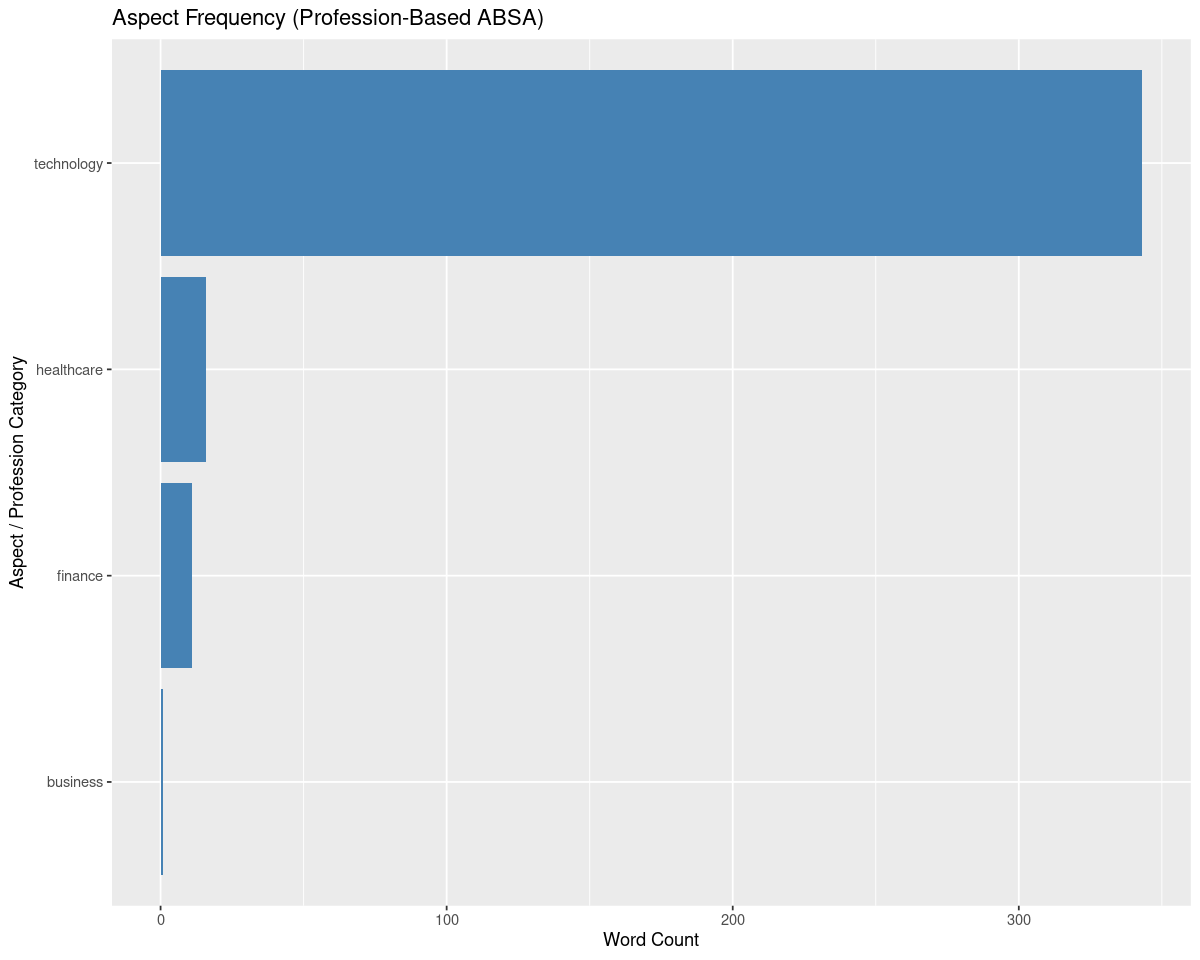

In [64]:
aspect_count <- aspect_words %>%
  count(aspect, sort = TRUE)

ggplot(aspect_count, aes(x = reorder(aspect, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Aspect Frequency (Profession-Based ABSA)",
    x = "Aspect / Profession Category",
    y = "Word Count"
  )


### 12.4. TOP WORDS PER ASPECT

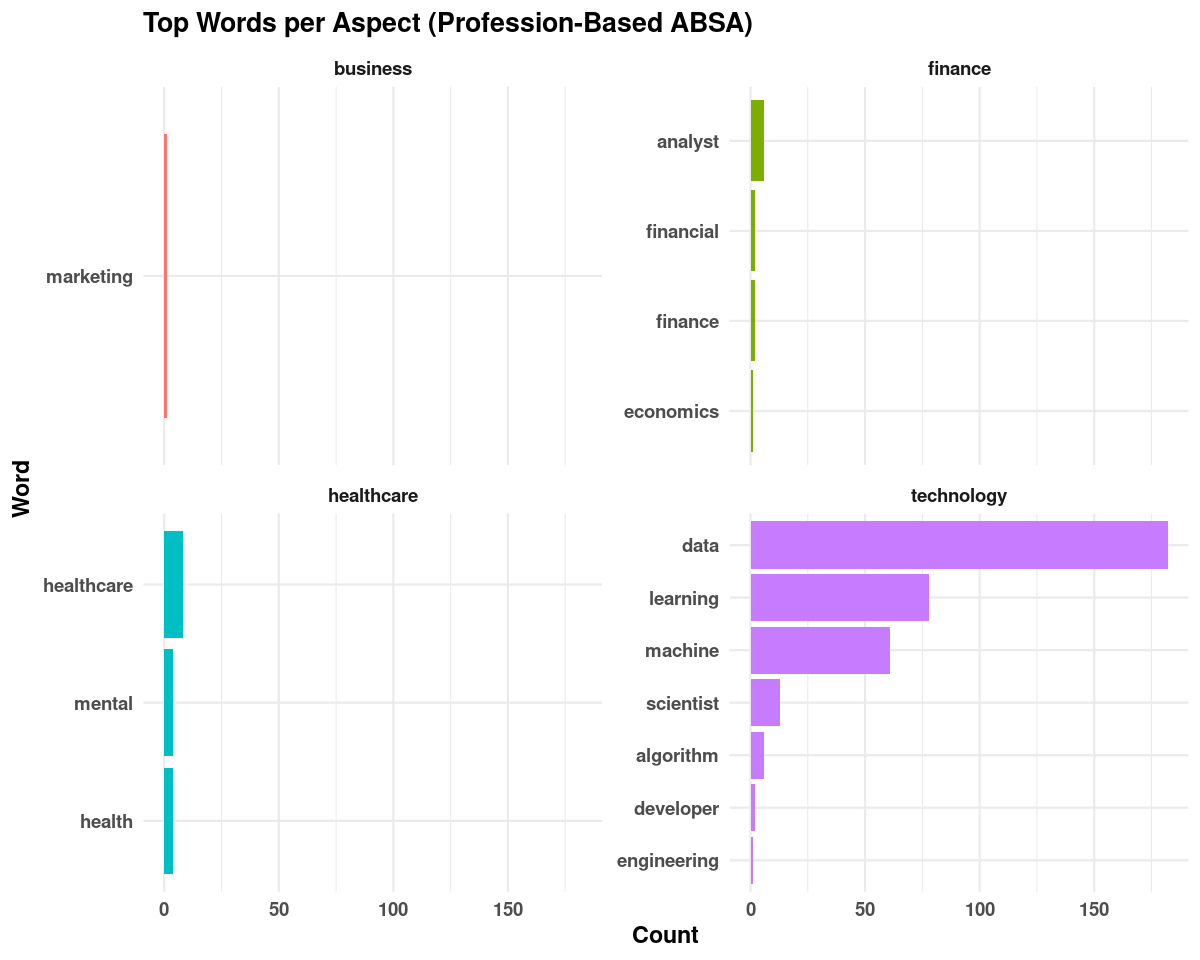

In [65]:
# Prepare top words per aspect
top_aspect_words <- aspect_words %>%
  count(aspect, word, sort = TRUE) %>%
  group_by(aspect) %>%
  slice_head(n = 10)

# Plot with bold styling
ggplot(top_aspect_words, aes(x = reorder(word, n), y = n, fill = aspect)) +
  geom_col(show.legend = FALSE) +
  coord_flip() +
  facet_wrap(~ aspect, scales = "free_y") +
  labs(title = "Top Words per Aspect (Profession-Based ABSA)", x = "Word", y = "Count") +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face="bold", size=16),
    axis.title = element_text(face="bold"),
    axis.text  = element_text(face="bold"),
    strip.text = element_text(face="bold")
  )


### 12.5. CAPTION-LEVEL ASPECT SCORE TABLE

In [66]:
caption_aspect_table <- instagram_scored %>%
  select(id, caption, aspect, n, aspect_strength)

print(caption_aspect_table)

# A tibble: 193 × 5
      id caption                                    aspect     n aspect_strength
   <int> <chr>                                      <chr>  <int>           <dbl>
 1     1 Here are some of the most important data … finan…     2             0.4
 2     1 Here are some of the most important data … techn…     3             0.6
 3     2 Here are some of the best data science pr… healt…     2             0.5
 4     2 Here are some of the best data science pr… techn…     2             0.5
 5     3 Learn how to train a machine learning mod… techn…     2             1  
 6     4 Here’s how you can write a Python program… NA         0             0  
 7     5 Plotting annotations while visualizing yo… techn…     1             1  
 8     6 Here are some of the most important soft … techn…     2             1  
 9     7 Learn how to analyze a candlestick chart … finan…     2             0.5
10     7 Learn how to analyze a candlestick chart … techn…     2             0.5
# ℹ 183 

## LOAD AND PREPARE THE DATASET: 
# 13. FOR TESTING AND TRANING THE DATASET: 

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.0     ✔ tibble  3.3.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ NLP::annotate()        masks ggplot2::annotate()
✖ readr::col_factor()    masks scales::col_factor()
✖ gridExtra::combine()   masks randomForest::combine(), dplyr::combine()
✖ scales::discard()      masks purrr::discard()
✖ e1071::element()       masks ggplot2::element()
✖ mice::filter()         masks dplyr::filter(), stats::filter()
✖ dplyr::lag()           masks stats::lag()
✖ caret::lift()          masks purrr::lift()
✖ randomForest::margin() masks ggplot2::margin()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Call:
lm(formula = Likes ~ ., data = df_num)

Residuals:
     Min       1Q   Median       3Q      Max 
-215.806  -23.323    0.633   20.550  274.103 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     55.783192  11.588473   4.814 3.36e-06 ***
Impressions     -0.017012   0.010852  -1.568  0.11892    
From.Home        0.030719   0.011511   2.669  0.00838 ** 
From.Hashtags    0.031378   0.011088   2.830  0.00524 ** 
From.Explore     0.021406   0.010906   1.963  0.05138 .  
From.Other       0.031382   0.011982   2.619  0.00965 ** 
Saves            0.257251   0.038780   6.634 4.60e-10 ***
Comments         4.679382   1.011103   4.628 7.50e-06 ***
Shares          -0.130471   0.425256  -0.307  0.75938    
Profile.Visits  -0.054181   0.057707  -0.939  0.34917    
Follows         -0.057095   0.104607  -0.546  0.58594    
Conversion.Rate -0.004395   0.138193  -0.032  0.97467    
Number_of_Words -0.413073   0.163607  -2.525  0.01253 *  
---
Signif. codes:  0 ‘

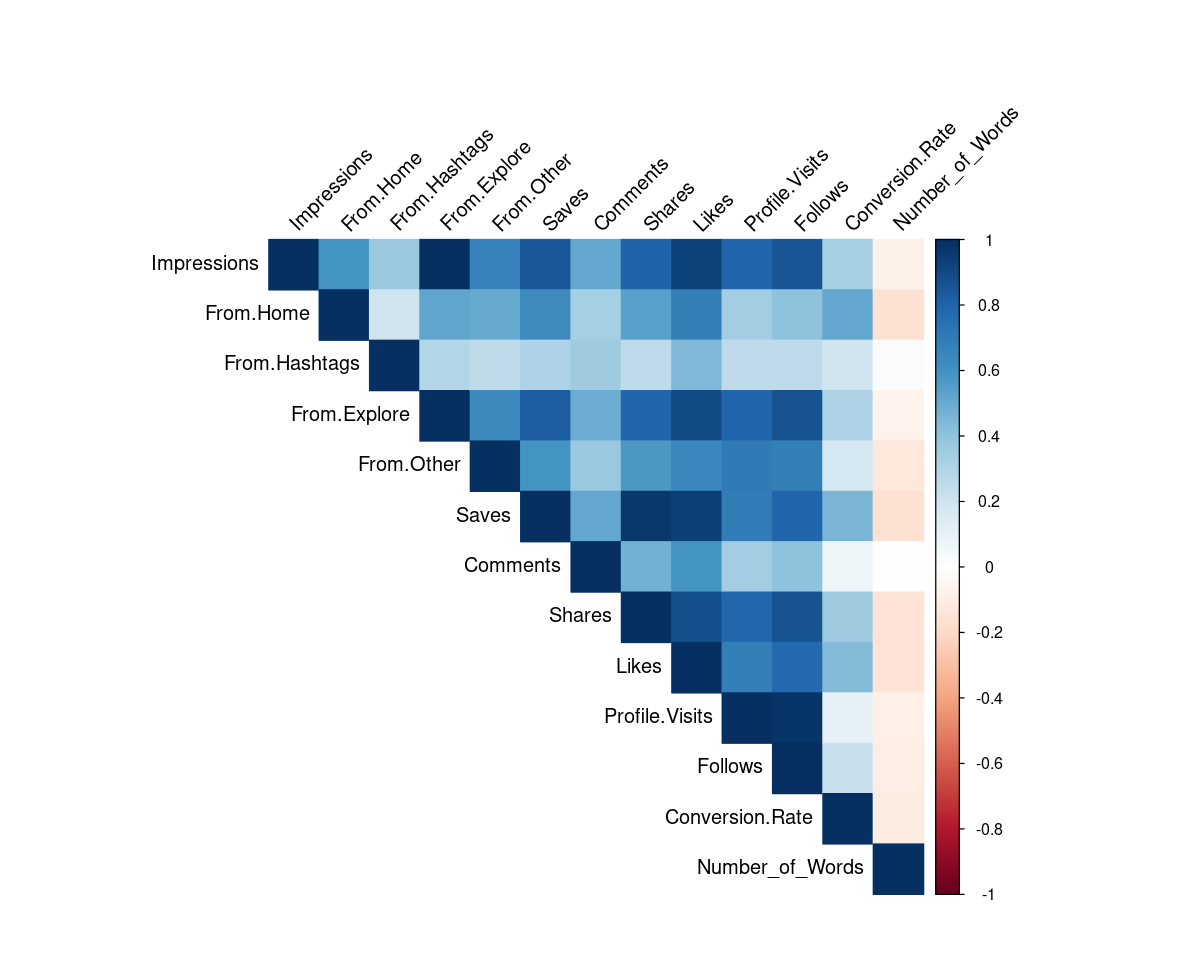

In [67]:
# ============================================================
# 1. Load packages
# ============================================================
library(tidyverse)
library(ggplot2)
library(reshape2)
library(corrplot)

# ============================================================
# 2. Load data
# ============================================================
df <- read.csv("Instagram-data_CURRENT.csv")

# ============================================================
# 3. Create Number_of_Words from caption column
#    (If caption column has another name, change it below)
# ============================================================
if ("Caption" %in% names(df)) {
  df$Number_of_Words <- sapply(strsplit(as.character(df$Caption), "\\s+"), length)
} else {
  message("⚠️ No 'Caption' column found. Provide correct text column name.")
  df$Number_of_Words <- NA
}

# ============================================================
# 4. Keep only numeric columns for correlation
# ============================================================
df_num <- df %>% select(where(is.numeric))

# Compute correlation matrix
corr_matrix <- cor(df_num, use = "pairwise.complete.obs")

# ============================================================
# 5. Correlation Heatmap
# ============================================================
corrplot(corr_matrix,
         method = "color",
         type = "upper",
         tl.col = "black",
         tl.srt = 45,
         number.cex = 0.7)

# ============================================================
# 6. Linear Regression Model:
#    lm(y ~ . + Number_of_Words)
#    Here y = Likes (change if needed)
# ============================================================

# Check dependent variable
if (!"Likes" %in% names(df)) stop("No 'Likes' column found in dataset!")

model <- lm(Likes ~ ., data = df_num)

# Summary
summary(model)

#  14. before & after MNAR code: 
## storing the new MNAR dataset. 

In [68]:
############################################################
### 1. Load Dataset
############################################################
df_file <- "Instagram-data_CURRENT.csv"

if (!file.exists(df_file)) stop("ERROR: Instagram-data_CURRENT.csv not found!")

df <- read.csv(df_file, stringsAsFactors = FALSE)
cat("Original dataset loaded. Rows:", nrow(df), "\n")

############################################################
### 2. Select numeric subset for MNAR
############################################################
df_num <- df %>% dplyr::select(where(is.numeric))
num_cols <- ncol(df_num)

cat("Numeric columns detected:", num_cols, "\n")


############################################################
### 3. Use YOUR MNAR INDEX LOGIC EXACTLY
############################################################

# Desired indices you gave earlier
desired_idx <- c(1,2,4,6,8,10)

# Keep only existing
desired_idx <- desired_idx[desired_idx <= num_cols]

if (length(desired_idx) == 0) {
  desired_idx <- unique(pmax(1, head(seq_len(num_cols), 2)))
}

cat("Will apply MNAR to numeric column indices:", paste(desired_idx, collapse=", "), "\n")
cat("Corresponding names:", paste(names(df_num)[desired_idx], collapse=", "), "\n")


############################################################
### 4. Build pattern vector EXACTLY as you used
############################################################

pattern_vec <- rep(1L, num_cols)
pattern_vec[desired_idx] <- 0L

cat("Pattern vector used for ampute():",
    paste(pattern_vec, collapse = ","), "\n")


############################################################
### 5. Run ampute, then fallback if needed
############################################################

set.seed(123)

ampute_out <- tryCatch({
  ampute(
    df_num,
    patterns = pattern_vec,
    freq = 1,
    mech = "MNAR",
    prop = 0.2
  )
}, error = function(e) {
  message("ampute() failed:", e$message)
  NULL
})

if (!is.null(ampute_out) && !is.null(ampute_out$amp)) {
  data_with_missing <- ampute_out$amp
  cat("ampute() succeeded. Summary:\n")
} else {
  cat("MNAR fallback starting...\n")
  data_with_missing <- df_num
  
  for (ci in desired_idx) {
    colname <- names(data_with_missing)[ci]
    colvals <- data_with_missing[[colname]]
    
    qq80 <- quantile(colvals, 0.8, na.rm = TRUE)
    sigma <- sd(colvals, na.rm = TRUE)
    sigma <- ifelse(is.na(sigma) || sigma == 0, 1, sigma)
    
    prob <- plogis((colvals - qq80) / sigma)
    prob[is.na(prob)] <- 0
    
    remove_mask <- runif(nrow(data_with_missing)) < (0.25 * prob)
    data_with_missing[[colname]][remove_mask] <- NA
  }
  
  cat("Manual MNAR fallback applied.\n")
}

print(colSums(is.na(data_with_missing)))


############################################################
### 6. Rebuild full dataset with MNAR numeric variables
############################################################

df_mnar <- df   # start with original dataset

# Replace only numeric columns
df_mnar[, names(df_num)] <- data_with_missing

cat("\nMNAR dataset created. Summary:\n")
print(colSums(is.na(df_mnar)))


############################################################
### 7. Save MNAR dataset
############################################################

write.csv(df_mnar, "Instagram_MNAR_missing.csv", row.names = FALSE)

cat("\n✔ Saved: Instagram_MNAR_missing.csv\n")


Original dataset loaded. Rows: 176 
Numeric columns detected: 12 
Will apply MNAR to numeric column indices: 1, 2, 4, 6, 8, 10 
Corresponding names: Impressions, From.Home, From.Explore, Saves, Shares, Profile.Visits 
Pattern vector used for ampute(): 0,0,1,0,1,0,1,0,1,0,1,1 
ampute() succeeded. Summary:
    Impressions       From.Home   From.Hashtags    From.Explore      From.Other 
             23              23               0              23               0 
          Saves        Comments          Shares           Likes  Profile.Visits 
             23               0              23               0              23 
        Follows Conversion.Rate 
              0               0 

MNAR dataset created. Summary:
           Date     Impressions       From.Home   From.Hashtags    From.Explore 
              0              23              23               0              23 
     From.Other           Saves        Comments          Shares           Likes 
              0              

## 15. Training the models and model comparision

Original dataset rows: 176 
MNAR dataset rows: 176 

MODEL FORMULA:
Impressions ~ From.Home + From.Hashtags + From.Explore + From.Other + 
    Saves + Comments + Shares + Likes + Profile.Visits + Follows + 
    Conversion.Rate + Number_of_Words


Loading required package: Formula

Loading required package: plotmo

Loading required package: plotrix


Attaching package: ‘plotrix’


The following object is masked from ‘package:scales’:

    rescale


The following object is masked from ‘package:syuzhet’:

    rescale





RMSE SUMMARY
Original Dataset:
       LM      MARS        RF 
 355.9181  381.2177 3070.3617 

MNAR Dataset:
      LM     MARS       RF 
2274.392 1648.726 2824.721 


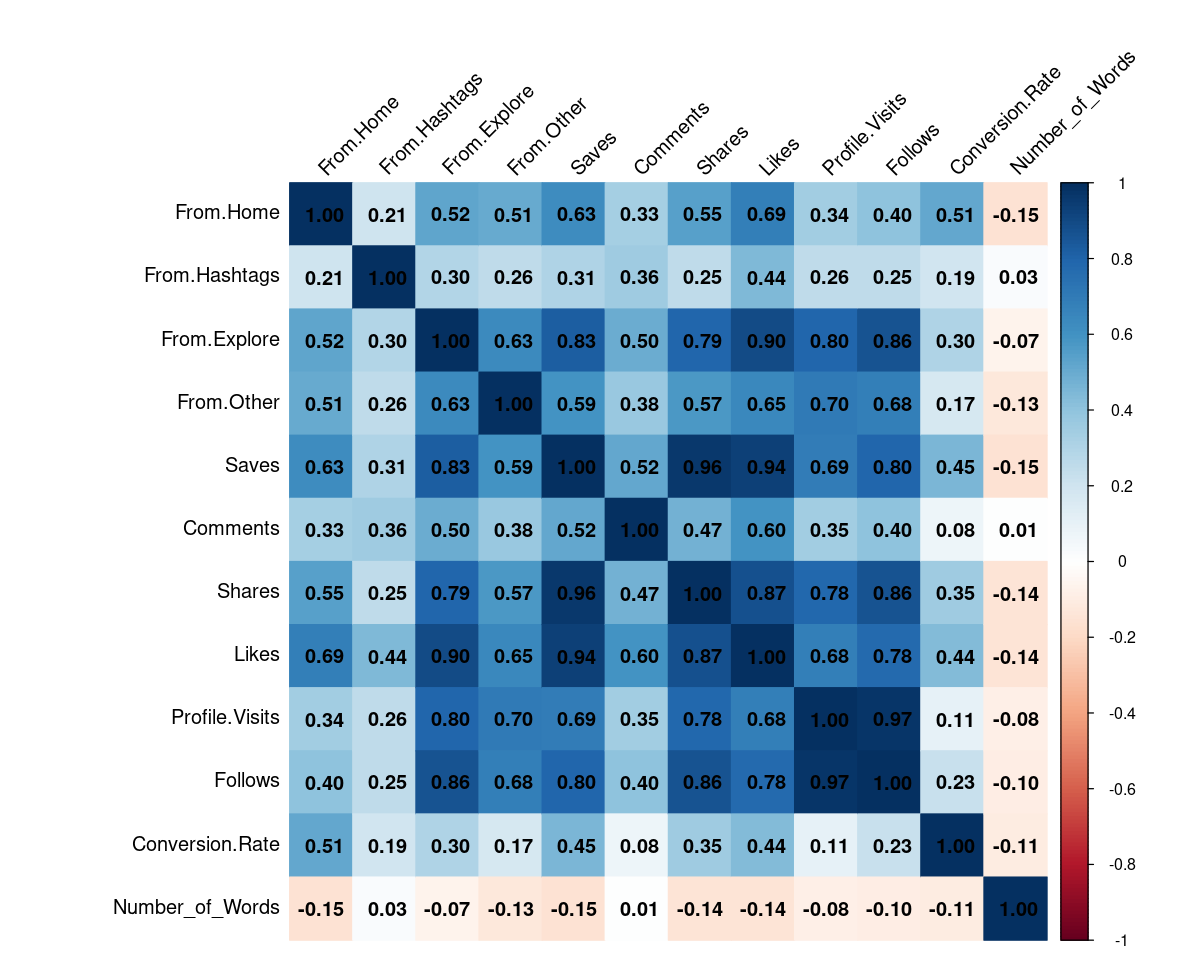

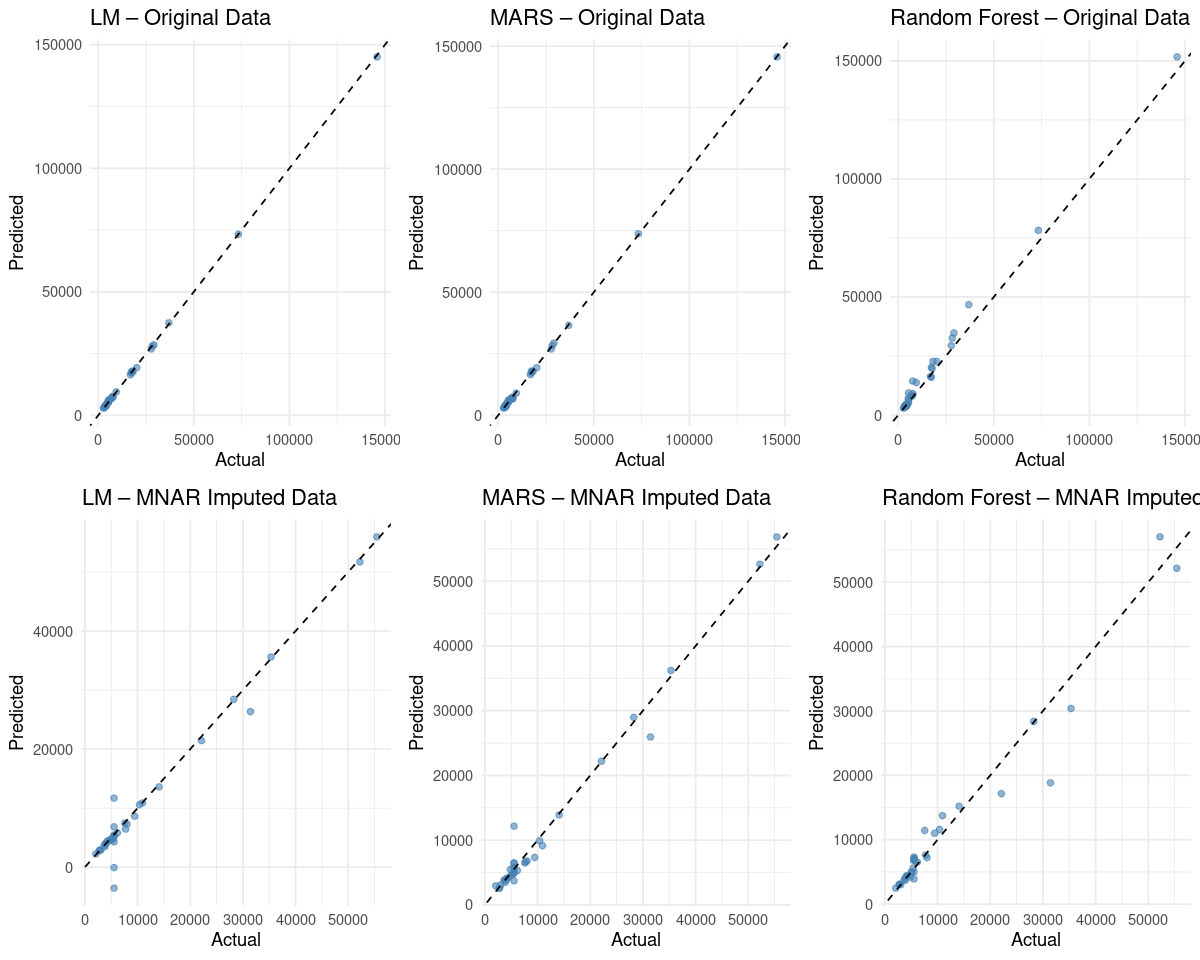

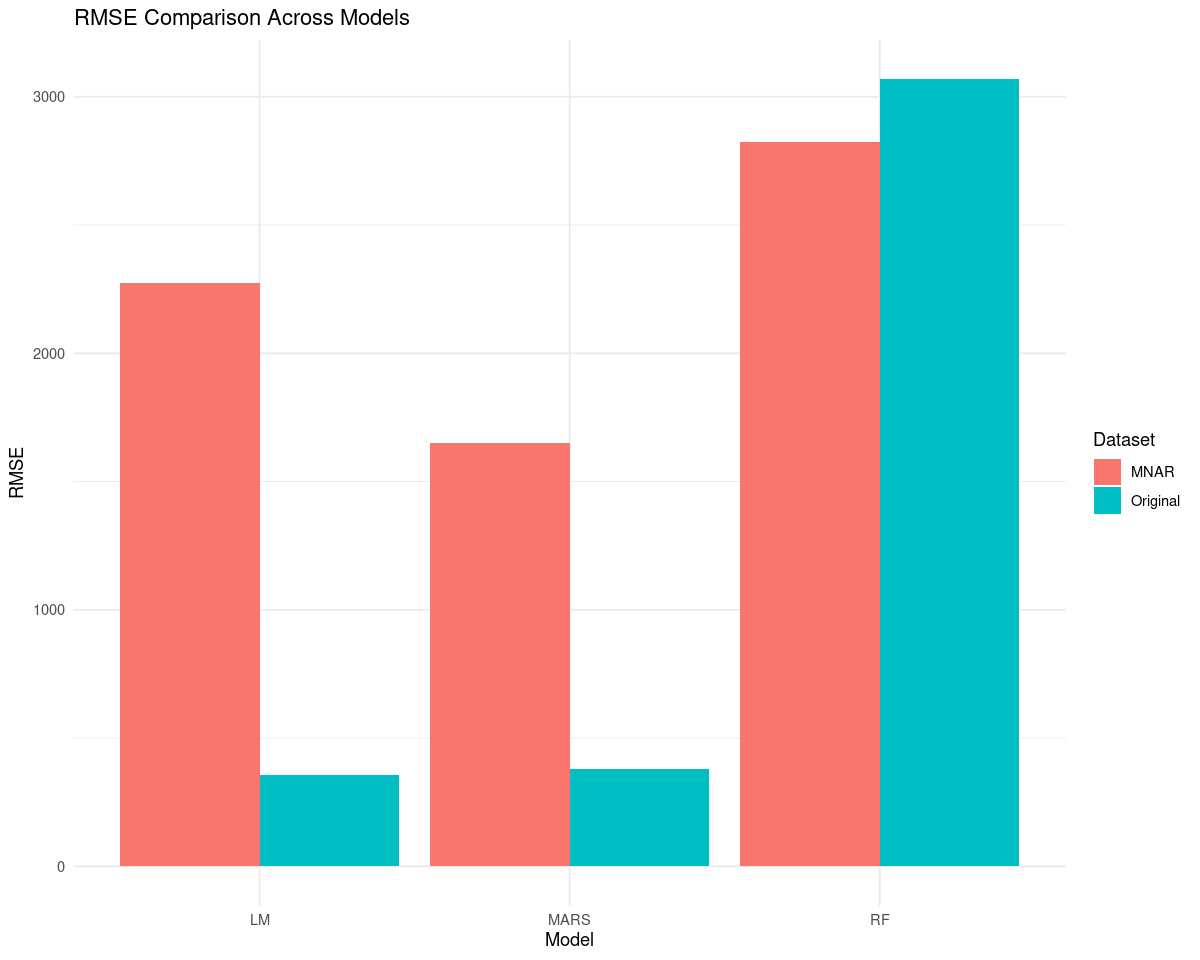

In [69]:
# =========================================================
# 1. LOAD DATA
# =========================================================
df <- read.csv("Instagram-data_CURRENT.csv")
df_mnar <- read.csv("Instagram_MNAR_missing.csv")

cat("Original dataset rows:", nrow(df), "\n")
cat("MNAR dataset rows:", nrow(df_mnar), "\n")


# =========================================================
# 2. ADD Number_of_Words FROM CAPTION
# =========================================================
df$Number_of_Words <- sapply(strsplit(as.character(df$Caption), "\\s+"), length)
df_mnar$Number_of_Words <- sapply(strsplit(as.character(df_mnar$Caption), "\\s+"), length)


# =========================================================
# 3. SELECT VARIABLES
# =========================================================
target <- "Impressions"

predictors <- c(
  "From.Home","From.Hashtags","From.Explore","From.Other",
  "Saves","Comments","Shares","Likes","Profile.Visits",
  "Follows","Conversion.Rate","Number_of_Words"
)

model_vars <- c(target, predictors)

df <- df[, model_vars]
df_mnar <- df_mnar[, model_vars]


# =========================================================
# 4. TRAIN–TEST SPLIT
# =========================================================
set.seed(123)

train_idx <- sample(1:nrow(df), 0.8*nrow(df))
train_df_orig <- df[train_idx, ]
test_df_orig  <- df[-train_idx, ]

train_idx_mnar <- sample(1:nrow(df_mnar), 0.8*nrow(df_mnar))
train_df_mnar <- df_mnar[train_idx_mnar, ]
test_df_mnar  <- df_mnar[-train_idx_mnar, ]


# =========================================================
# 5. IMPUTE MNAR MEDIANS
# =========================================================
impute_median <- function(dat){
  for(col in names(dat)){
    if(is.numeric(dat[[col]])){
      dat[[col]][is.na(dat[[col]])] <- median(dat[[col]], na.rm = TRUE)
    }
  }
  return(dat)
}

train_df_mnar <- impute_median(train_df_mnar)
test_df_mnar  <- impute_median(test_df_mnar)


# =========================================================
# 6. MODEL FORMULA
# =========================================================
model_formula <- as.formula(paste(target, "~", paste(predictors, collapse=" + ")))

cat("\nMODEL FORMULA:\n")
print(model_formula)


# =========================================================
# 7. FIT MODELS (LM, MARS, RF)
# =========================================================
library(earth)
library(randomForest)

fit_models <- function(train_df) {
  list(
    LM   = lm(model_formula, data=train_df),
    MARS = earth(model_formula, data=train_df),
    RF   = randomForest(model_formula, data=train_df, ntree=300)
  )
}

models_orig <- fit_models(train_df_orig)
models_mnar <- fit_models(train_df_mnar)


# =========================================================
# 8. RMSE FUNCTION
# =========================================================
rmse <- function(actual, predicted){
  sqrt(mean((actual - predicted)^2))
}

evaluate_models <- function(model_list, test_df){
  sapply(model_list, function(m){
    preds <- predict(m, test_df)
    preds <- as.numeric(preds)   # FIX FOR MARS
    rmse(test_df[[target]], preds)
  })
}

rmse_orig <- evaluate_models(models_orig, test_df_orig)
rmse_mnar <- evaluate_models(models_mnar, test_df_mnar)

cat("\n=======================\nRMSE SUMMARY\n=======================\n")
cat("Original Dataset:\n")
print(rmse_orig)

cat("\nMNAR Dataset:\n")
print(rmse_mnar)


# =========================================================
# 9. CORRELATION PLOT
# =========================================================
library(ggplot2)
library(corrplot)

corr_data <- df[, predictors]
corr_mat <- cor(corr_data, use="pairwise.complete.obs")

corrplot(corr_mat, method="color", addCoef.col="black",
         tl.col="black", tl.srt=45)


# =========================================================
# 10. PLOTTING FUNCTION (FIXED FOR MARS)
# =========================================================
plot_model <- function(model, test_df, title){
  preds <- predict(model, test_df)
  preds <- as.numeric(preds)  # IMPORTANT FIX

  dfplot <- data.frame(
    actual = test_df[[target]],
    predicted = preds
  )

  ggplot(dfplot, aes(x = actual, y = predicted)) +
    geom_point(alpha = 0.6, color = "steelblue") +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
    theme_minimal() +
    labs(title = title, x = "Actual", y = "Predicted")
}


# =========================================================
# 11. GENERATE ALL 6 MODEL PLOTS
# =========================================================
p1 <- plot_model(models_orig$LM,   test_df_orig, "LM – Original Data")
p2 <- plot_model(models_orig$MARS, test_df_orig, "MARS – Original Data")
p3 <- plot_model(models_orig$RF,   test_df_orig, "Random Forest – Original Data")

p4 <- plot_model(models_mnar$LM,   test_df_mnar, "LM – MNAR Imputed Data")
p5 <- plot_model(models_mnar$MARS, test_df_mnar, "MARS – MNAR Imputed Data")
p6 <- plot_model(models_mnar$RF,   test_df_mnar, "Random Forest – MNAR Imputed Data")


# =========================================================
# 12. SHOW PLOTS SIDE-BY-SIDE
# =========================================================
library(gridExtra)

grid.arrange(p1, p2, p3, p4, p5, p6, ncol = 3)


# =========================================================
# 13. RMSE BAR CHART
# =========================================================
rmse_df <- data.frame(
  Model = rep(c("LM", "MARS", "RF"), 2),
  Dataset = rep(c("Original", "MNAR"), each = 3),
  RMSE = c(rmse_orig, rmse_mnar)
)

ggplot(rmse_df, aes(x = Model, y = RMSE, fill = Dataset)) +
  geom_bar(stat = "identity", position = "dodge") +
  theme_minimal() +
  labs(title="RMSE Comparison Across Models",
       y="RMSE", x="Model")
